## sca

In [2]:
# 导入必要的库
# seaborn: 用于创建统计图形，提供高层次接口
# matplotlib.pyplot: seaborn底层绘图库，用于基础绘图功能
# pandas: 数据处理和分析库，用于加载和操作数据集
# numpy: 数值计算库，用于数组操作和数学函数
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# 设置seaborn绘图风格为"whitegrid"
# "whitegrid": 白色背景带网格线，便于阅读数据点
sns.set_style("whitegrid")

# 设置全局字体家族
# 优先使用'Times New Roman'(英文西文字体)，备选'STsong'(中文字体)
# 确保图表中英文和中文都能正确显示
plt.rcParams['font.family'] = ['Times New Roman', 'STsong']

# 禁用matplotlib中负号显示为方块的问题
# axes.unicode_minus=False: 确保负号正确显示为'-'而非Unicode方块
plt.rcParams['axes.unicode_minus'] = False

# 加载并预处理企鹅数据集
# sns.load_dataset('penguins'): 从seaborn内置数据集加载企鹅数据
# .dropna(): 删除包含任何缺失值(NA)的行，确保数据完整性
penguins = sns.load_dataset('penguins').dropna()

# 加载小费数据集
# sns.load_dataset('tips'): 从seaborn内置数据集加载餐厅小费数据
# 包含总账单、消费时间、小费金额、性别、吸烟状况等信息
tips = sns.load_dataset('tips')

# 打印企鹅数据集的基本信息
# f-string格式化输出: 显示数据集的行数和列数
# penguins.shape: 返回元组(行数, 列数)，如(333, 7)
print(f"数据集形状: {penguins.shape}")

# 打印空行，用于格式化输出
print()

# 打印散点图特点说明 - 第一行
# f-string格式化: "Axes-level散点图"指seaborn中基于Axes的散点图函数
print(f"\nScatterplot特点: Axes-level散点图")

# 打印散点图特点说明 - 第二行
# 说明散点图的主要用途: 展示两个连续数值变量之间的关系
print("适合展示两个数值变量的关系")

# 打印散点图特点说明 - 第三行
# 说明seaborn散点图的多维度映射功能:
# hue: 按类别着色; size: 按数值改变点大小; style: 按类别改变标记样式
print("支持多维度映射(hue/size/style)")

数据集形状: (333, 7)


Scatterplot特点: Axes-level散点图
适合展示两个数值变量的关系
支持多维度映射(hue/size/style)


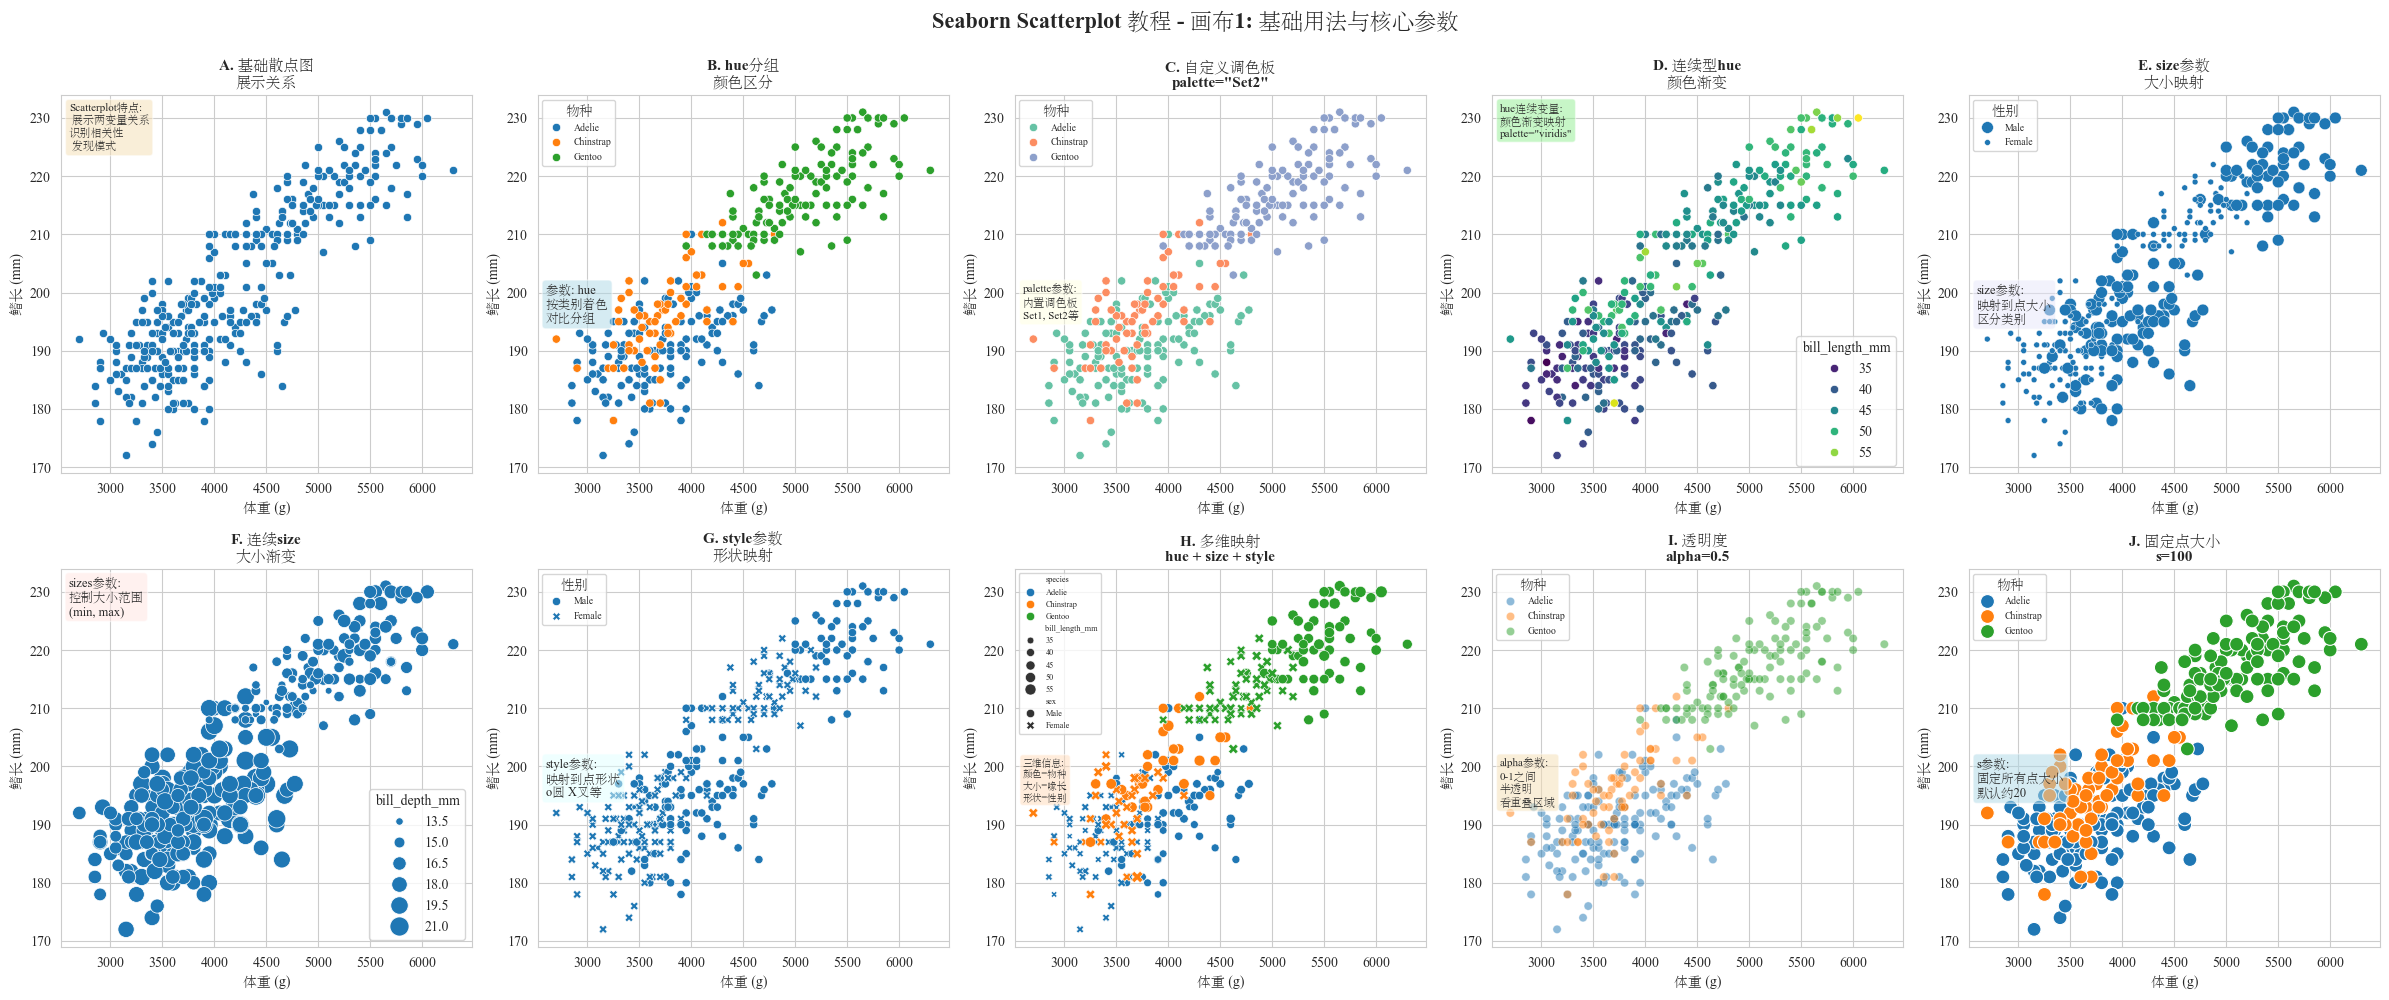

In [3]:
# ============================================================
# 画布 1: 基础用法和核心参数
# ============================================================
fig1, axes1 = plt.subplots(2, 5, figsize=(24, 10))  # 创建2行5列子图网格,figsize=(宽24英寸,高10英寸)控制整体画布尺寸
fig1.suptitle('Seaborn Scatterplot 教程 - 画布1: 基础用法与核心参数',
              fontsize=16,  # 标题字体大小16pt
              fontweight='bold',  # 标题粗体显示
              y=0.995)  # 标题垂直位置(0-1范围,0.995=距离顶部0.5%)

# ========== 子图 A：最基础的散点图 ==========
ax = axes1[0, 0]  # 获取第1行第1列子图(行索引0,列索引0)
sns.scatterplot(data=penguins, x='body_mass_g', y='flipper_length_mm',
                ax=ax)  # 基础散点图:数据=企鹅数据集,X=体重(克),Y=鳍长(毫米),ax=指定子图对象
ax.set_title('A. 基础散点图\n展示关系', fontsize=11,  # 子图标题:11pt字体,含换行符\n实现两行显示
             fontweight='bold')  # 标题粗体强调
ax.set_xlabel('体重 (g)', fontsize=10)  # X轴标签文字"体重 (g)",字体大小10pt
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # Y轴标签文字"鳍长 (mm)",字体大小10pt

# 添加说明文本框:位置(左2%,上98%),相对坐标系,8pt字体,顶部对齐,圆角背景框(小麦色,50%透明度)
ax.text(0.02,  # 水平位置:距离左边2%(0-1相对值)
        0.98,  # 垂直位置:距离顶部2%(0-1相对值)
        'Scatterplot特点:\n 展示两变量关系\n识别相关性\n 发现模式',  # 多行文本内容(用\n换行)
        transform=ax.transAxes,  # 坐标变换:使用Axes相对坐标系(0-1范围)
        fontsize=8,  # 文本字体大小8pt
        verticalalignment='top',  # 垂直对齐:文本顶部与指定位置对齐
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))  # 背景框:圆角样式,小麦色填充,50%透明度

# ========== 子图 B：添加hue分组 ==========
ax = axes1[0, 1]  # 获取第1行第2列子图
sns.scatterplot(data=penguins,
                x='body_mass_g',  # X轴变量:体重(克)
                y='flipper_length_mm',  # Y轴变量:鳍长(毫米)
                hue='species',  # 颜色分组:按物种类别(Adelie/Chinstrap/Gentoo)自动分配颜色
                ax=ax)  # 指定绘制子图
ax.set_title('B. hue分组\n颜色区分', fontsize=11, fontweight='bold')  # 子图标题:11pt粗体
ax.set_xlabel('体重 (g)', fontsize=10)  # X轴标签10pt
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # Y轴标签10pt
sns.move_legend(ax, loc='upper left', fontsize=7,  # 图例字体7pt
                title='物种')  # 图例标题文字"物种"

# 添加参数说明:位置(左2%,中50%),9pt字体,浅蓝色半透明圆角背景框
ax.text(0.02,  # 左2%位置
        0.50,  # 垂直中部50%
        '参数: hue\n按类别着色\n对比分组',  # 说明hue参数作用
        transform=ax.transAxes,  # Axes相对坐标
        fontsize=9,  # 9pt字体
        verticalalignment='top',  # 顶部对齐
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝背景,50%透明

# ========== 子图 C：自定义调色板 ==========
ax = axes1[0, 2]  # 获取第1行第3列子图
sns.scatterplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                hue='species',
                palette='Set2',  # 自定义调色板:Seaborn内置Set2(8色柔和调色板)
                ax=ax)
ax.set_title('C. 自定义调色板\npalette="Set2"', fontsize=11,
             fontweight='bold')  # 标题显示调色板名称
ax.set_xlabel('体重 (g)', fontsize=10)
ax.set_ylabel('鳍长 (mm)', fontsize=10)
sns.move_legend(ax, loc='upper left', fontsize=7, title='物种')  # 图例左上角7pt

# 添加调色板说明:浅黄色半透明背景,8pt字体
ax.text(0.02,
        0.50,
        'palette参数:\n内置调色板\nSet1, Set2等',  # 列出常见调色板选项
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

# ========== 子图 D：连续型hue ==========
ax = axes1[0, 3]  # 获取第1行第4列子图
sns.scatterplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                hue='bill_length_mm',  # 连续变量hue:喙长(毫米)映射到颜色渐变
                palette='viridis',  # 连续调色板:viridis(感知均匀,暗->亮:紫-蓝-绿-黄)
                ax=ax)
ax.set_title('D. 连续型hue\n颜色渐变', fontsize=11, fontweight='bold')
ax.set_xlabel('体重 (g)', fontsize=10)
ax.set_ylabel('鳍长 (mm)', fontsize=10)

# 添加连续hue说明:浅绿色背景,位置左上
ax.text(0.02,
        0.98,
        'hue连续变量:\n颜色渐变映射\npalette="viridis"',
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# ========== 子图 E：size参数 - 分类 ==========
ax = axes1[0, 4]  # 获取第1行第5列子图
sns.scatterplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                size='sex',  # 分类size:按性别(Male/Female)分配两种固定点大小
                ax=ax)
ax.set_title('E. size参数\n大小映射', fontsize=11, fontweight='bold')
ax.set_xlabel('体重 (g)', fontsize=10)
ax.set_ylabel('鳍长 (mm)', fontsize=10)
sns.move_legend(ax, loc='upper left', fontsize=7, title='性别')  # 图例显示性别

# 添加size分类说明:淡紫色背景,中部位置
ax.text(0.02,
        0.50,
        'size参数:\n映射到点大小\n区分类别',
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))

# ========== 子图 F：size参数 - 连续 ==========
ax = axes1[1, 0]  # 获取第2行第1列子图
sns.scatterplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                size='bill_depth_mm',  # 连续size:喙深度(毫米)映射到点大小
                sizes=(20, 200),  # 大小范围:最小20像素,最大200像素
                ax=ax)
ax.set_title('F. 连续size\n大小渐变', fontsize=11, fontweight='bold')
ax.set_xlabel('体重 (g)', fontsize=10)
ax.set_ylabel('鳍长 (mm)', fontsize=10)

# 添加sizes参数说明:粉红背景,左上位置
ax.text(0.02,
        0.98,
        'sizes参数:\n控制大小范围\n(min, max)',
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))

# ========== 子图 G：style参数 ==========
ax = axes1[1, 1]  # 获取第2行第2列子图
sns.scatterplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                style='sex',  # 形状分组:Male=圆圈,Female=X叉标记
                ax=ax)
ax.set_title('G. style参数\n形状映射', fontsize=11, fontweight='bold')
ax.set_xlabel('体重 (g)', fontsize=10)
ax.set_ylabel('鳍长 (mm)', fontsize=10)
sns.move_legend(ax, loc='upper left', fontsize=7, title='性别')

# 添加style说明:浅青色背景
ax.text(0.02,
        0.50,
        'style参数:\n映射到点形状\no圆 X叉等',
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))

# ========== 子图 H：hue + size + style组合 ==========
ax = axes1[1, 2]  # 获取第2行第3列子图
sns.scatterplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                hue='species',  # 颜色=物种(3类)
                size='bill_length_mm',  # 大小=喙长(连续)
                style='sex',  # 形状=性别(2类)
                ax=ax)  # 三维可视化组合
ax.set_title('H. 多维映射\nhue + size + style', fontsize=11,
             fontweight='bold')
ax.set_xlabel('体重 (g)', fontsize=10)
ax.set_ylabel('鳍长 (mm)', fontsize=10)
sns.move_legend(ax, loc='upper left', fontsize=6)  # 6pt字体(3维信息多,缩小避免拥挤)

# 添加三维说明:桃色背景,7pt字体
ax.text(0.02,
        0.50,
        '三维信息:\n颜色=物种\n大小=喙长\n形状=性别',
        transform=ax.transAxes,
        fontsize=7,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))

# ========== 子图 I：调整透明度alpha ==========
ax = axes1[1, 3]  # 获取第2行第4列子图
sns.scatterplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                hue='species',
                alpha=0.5,  # 透明度:0=全透明,1=不透明,0.5=半透明显示重叠区域
                ax=ax)
ax.set_title('I. 透明度\nalpha=0.5', fontsize=11, fontweight='bold')
ax.set_xlabel('体重 (g)', fontsize=10)
ax.set_ylabel('鳍长 (mm)', fontsize=10)
sns.move_legend(ax, loc='upper left', fontsize=7, title='物种')

# 添加alpha说明:小麦色背景
ax.text(0.02,
        0.50,
        'alpha参数:\n0-1之间\n半透明\n看重叠区域',
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ========== 子图 J：固定大小s ==========
ax = axes1[1, 4]  # 获取第2行第5列子图
sns.scatterplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                hue='species',
                s=100,  # 固定点大小:所有点统一100像素(默认约20像素)
                ax=ax)
ax.set_title('J. 固定点大小\ns=100', fontsize=11, fontweight='bold')
ax.set_xlabel('体重 (g)', fontsize=10)
ax.set_ylabel('鳍长 (mm)', fontsize=10)
sns.move_legend(ax, loc='upper left', fontsize=7, title='物种')

# 添加s参数说明:浅蓝色背景
ax.text(0.02,
        0.50,
        's参数:\n固定所有点大小\n默认约20',
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.savefig('./scatters.pdf', dpi=300,  # 保存为PDF:300dpi高分辨率
            bbox_inches='tight',  # 边界框:紧凑裁剪去除多余空白
            pad_inches=0.1)  # 边距:0.1英寸周围留白
plt.tight_layout()  # 自动调整:优化子图间距,防止标题/标签重叠
plt.show()  # 显示完整图形窗口

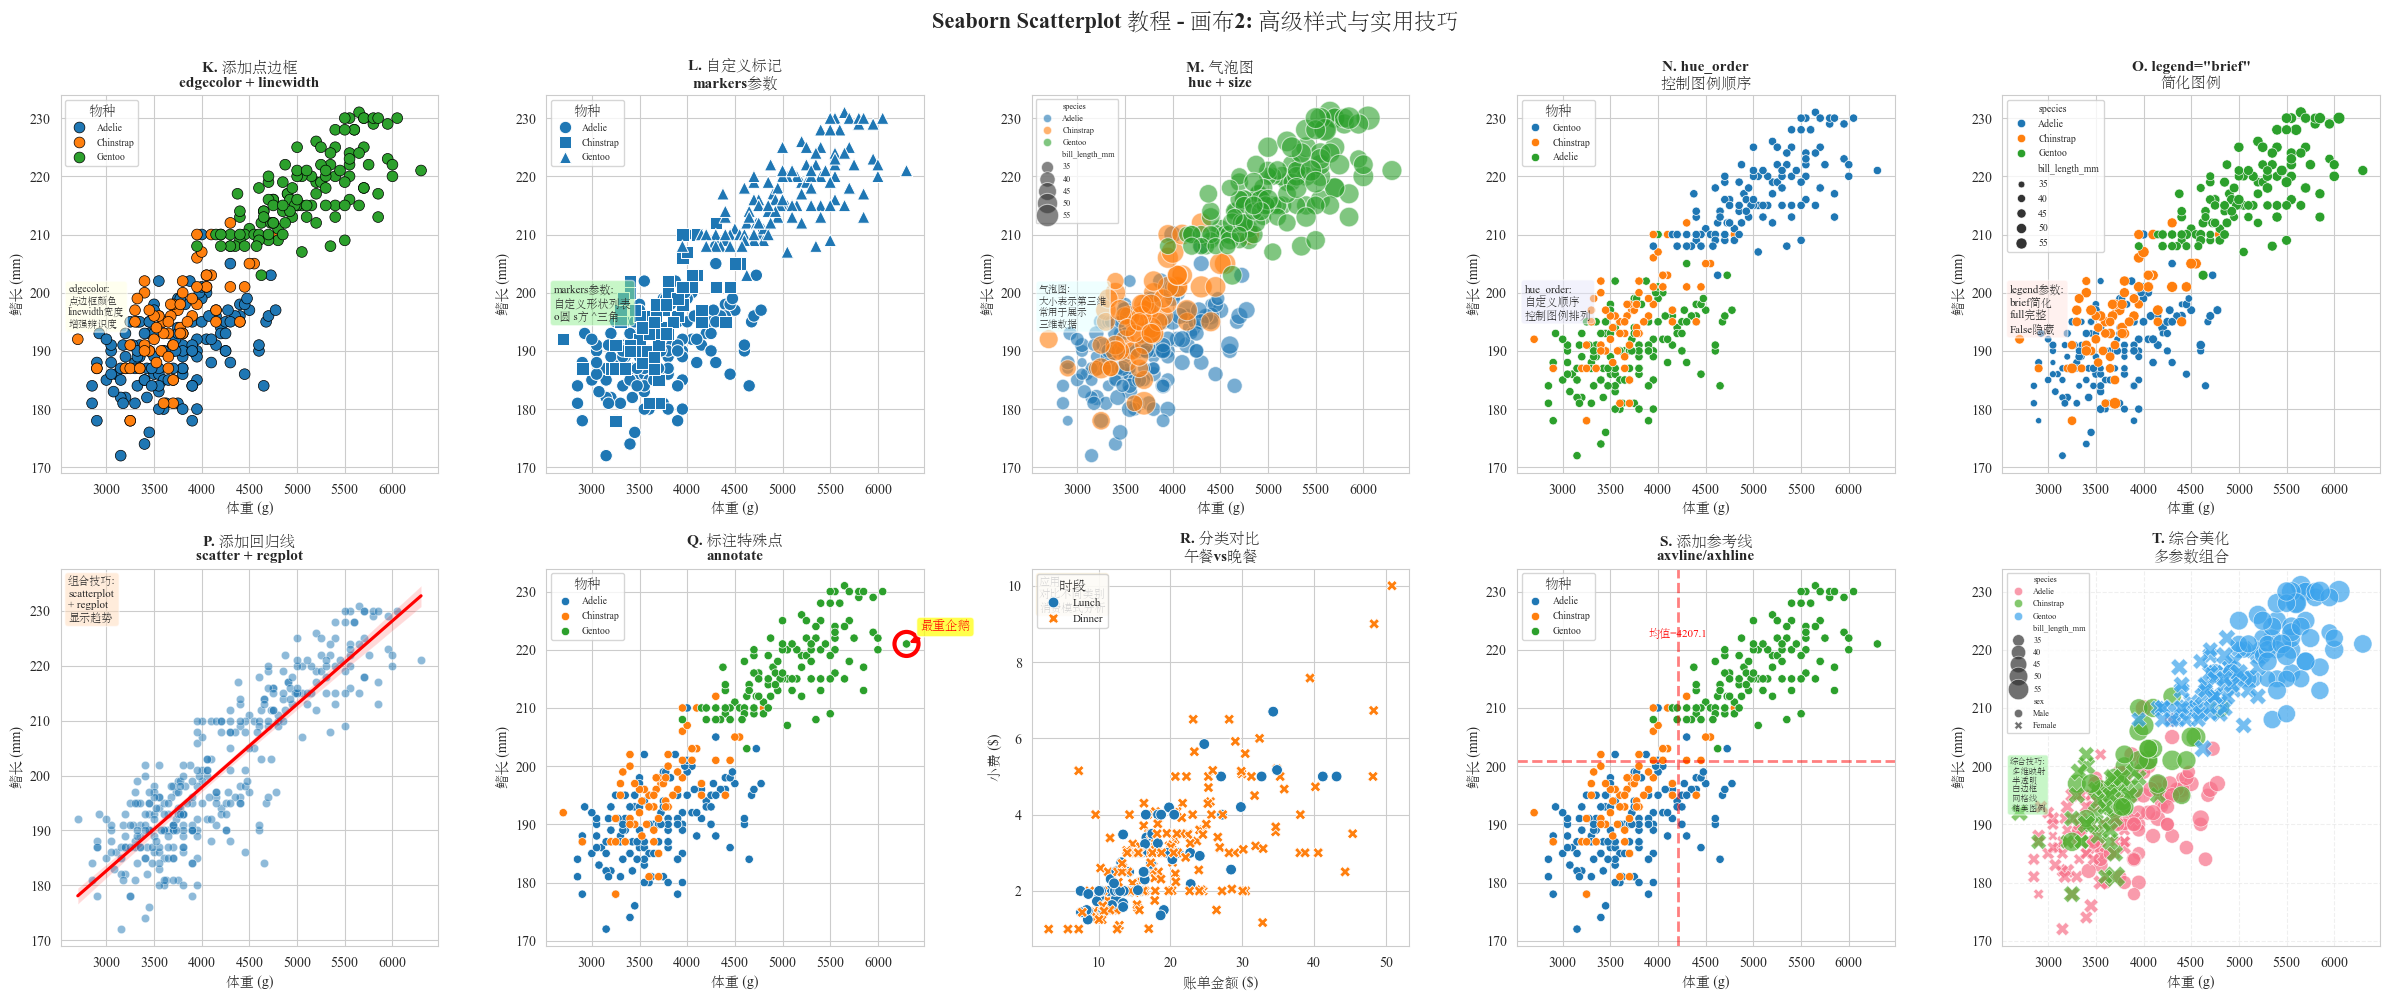

In [4]:
# ============================================================
# 画布 2: 高级样式和实用技巧
# ============================================================
fig2, axes2 = plt.subplots(2, 5, figsize=(24, 10))  # 创建2行5列子图网格,figsize=(宽24英寸,高10英寸)控制整体画布尺寸
fig2.suptitle('Seaborn Scatterplot 教程 - 画布2: 高级样式与实用技巧',
              fontsize=16,  # 标题字体大小16pt
              fontweight='bold',  # 标题粗体显示
              y=0.995)  # 标题垂直位置(0-1范围,0.995=距离顶部0.5%)

# ========== 子图 K：添加边框 ==========
ax = axes2[0, 0]  # 获取第1行第1列子图(行索引0,列索引0)
sns.scatterplot(data=penguins,
                x='body_mass_g',  # X轴变量:体重(克)
                y='flipper_length_mm',  # Y轴变量:鳍长(毫米)
                hue='species',  # 颜色分组:按物种类别自动分配颜色
                edgecolor='black',  # 点边框颜色:黑色轮廓
                linewidth=0.5,  # 边框线宽:0.5pt细线
                s=60,  # 固定点大小:60像素
                ax=ax)  # 指定绘制子图
ax.set_title('K. 添加点边框\nedgecolor + linewidth', fontsize=11,  # 子图标题:11pt字体,含换行符\n实现两行显示
             fontweight='bold')  # 标题粗体强调
ax.set_xlabel('体重 (g)', fontsize=10)  # X轴标签文字"体重 (g)",字体大小10pt
ax.set_ylabel('鳍长 (mm)', fontsize=10)  # Y轴标签文字"鳍长 (mm)",字体大小10pt
sns.move_legend(ax, loc='upper left',  # 图例位置:左上角
                fontsize=7, title='物种')  # 图例字体7pt,标题文字"物种"

# 添加边框参数说明:位置(左2%,中50%),7pt字体,浅黄色半透明圆角背景框
ax.text(0.02,  # 水平位置:距离左边2%(0-1相对值)
        0.50,  # 垂直位置:中部50%
        'edgecolor:\n点边框颜色\nlinewidth宽度\n增强辨识度',  # 多行文本说明边框参数
        transform=ax.transAxes,  # 坐标变换:使用Axes相对坐标系(0-1范围)
        fontsize=7,  # 文本字体大小7pt
        verticalalignment='top',  # 垂直对齐:文本顶部与指定位置对齐
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 背景框:圆角样式,浅黄色填充,50%透明度

# ========== 子图 L：自定义markers ==========
ax = axes2[0, 1]  # 获取第1行第2列子图
sns.scatterplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                style='species',  # 形状分组:按物种类别分配不同标记
                markers=['o', 's', '^'],  # 自定义标记列表:o=圆圈,s=方块,^=上三角(对应3种物种顺序)
                s=80,  # 固定点大小:80像素
                ax=ax)
ax.set_title('L. 自定义标记\nmarkers参数', fontsize=11, fontweight='bold')  # 子图标题:11pt粗体
ax.set_xlabel('体重 (g)', fontsize=10)
ax.set_ylabel('鳍长 (mm)', fontsize=10)
sns.move_legend(ax, loc='upper left', fontsize=7, title='物种')  # 图例左上角7pt

# 添加markers说明:浅绿色背景,中部位置
ax.text(0.02,
        0.50,
        'markers参数:\n自定义形状列表\no圆 s方 ^三角',  # 列出具体标记符号含义
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# ========== 子图 M：气泡图 ==========
ax = axes2[0, 2]  # 获取第1行第3列子图
sns.scatterplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                hue='species',  # 颜色=物种(3类)
                size='bill_length_mm',  # 大小=喙长(连续变量)
                sizes=(50, 300),  # 大小范围:最小50像素,最大300像素
                alpha=0.6,  # 透明度:60%不透明(0.6=轻微透明)
                ax=ax)
ax.set_title('M. 气泡图\nhue + size', fontsize=11, fontweight='bold')
ax.set_xlabel('体重 (g)', fontsize=10)
ax.set_ylabel('鳍长 (mm)', fontsize=10)
sns.move_legend(ax, loc='upper left', fontsize=6)  # 图例6pt(信息多,缩小字体)

# 添加气泡图说明:浅青色背景
ax.text(0.02,
        0.50,
        '气泡图:\n大小表示第三维\n常用于展示\n三维数据',
        transform=ax.transAxes,
        fontsize=7,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))

# ========== 子图 N：hue_order控制顺序 ==========
ax = axes2[0, 3]  # 获取第1行第4列子图
sns.scatterplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                hue='species',
                hue_order=['Gentoo', 'Chinstrap', 'Adelie'],  # 自定义颜色顺序:Gentoo第一,Adelie最后
                ax=ax)
ax.set_title('N. hue_order\n控制图例顺序', fontsize=11, fontweight='bold')
ax.set_xlabel('体重 (g)', fontsize=10)
ax.set_ylabel('鳍长 (mm)', fontsize=10)
sns.move_legend(ax, loc='upper left', fontsize=7, title='物种')

# 添加hue_order说明:淡紫色背景
ax.text(0.02,
        0.50,
        'hue_order:\n自定义顺序\n控制图例排列',
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))

# ========== 子图 O：legend参数 ==========
ax = axes2[0, 4]  # 获取第1行第5列子图
sns.scatterplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                hue='species',
                size='bill_length_mm',
                legend='brief',  # 图例模式:brief=只显示hue分类,忽略size连续值
                ax=ax)
ax.set_title('O. legend="brief"\n简化图例', fontsize=11, fontweight='bold')
ax.set_xlabel('体重 (g)', fontsize=10)
ax.set_ylabel('鳍长 (mm)', fontsize=10)
sns.move_legend(ax, loc='upper left', fontsize=7)  # 移动简化图例

# 添加legend说明:粉红色背景
ax.text(0.02,
        0.50,
        'legend参数:\nbrief简化\nfull完整\nFalse隐藏',  # 列出3种图例模式
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.5))

# ========== 子图 P：添加回归线 ==========
ax = axes2[1, 0]  # 获取第2行第1列子图
sns.scatterplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                alpha=0.5,  # 散点半透明:便于观察回归线
                ax=ax)
# 添加回归线(不显示散点,仅趋势线)
sns.regplot(data=penguins,
            x='body_mass_g',
            y='flipper_length_mm',
            scatter=False,  # scatter=False:只绘制回归线,不绘制散点
            color='red',  # 回归线颜色:红色
            ax=ax)  # 指定同一子图
ax.set_title('P. 添加回归线\nscatter + regplot', fontsize=11, fontweight='bold')
ax.set_xlabel('体重 (g)', fontsize=10)
ax.set_ylabel('鳍长 (mm)', fontsize=10)

# 添加组合技巧说明:桃色背景,左上位置
ax.text(0.02,
        0.98,
        '组合技巧:\nscatterplot\n+ regplot\n显示趋势',
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='peachpuff', alpha=0.5))

# ========== 子图 Q：标注特殊点 ==========
ax = axes2[1, 1]  # 获取第2行第2列子图
sns.scatterplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                hue='species',
                ax=ax)
# 找到最重的企鹅:返回最大值索引
max_mass_idx = penguins['body_mass_g'].idxmax()
# 获取最重企鹅整行数据
max_mass_row = penguins.loc[max_mass_idx]
# 绘制高亮特殊点:红色空心大圆(300像素),3pt粗红边框
ax.scatter([max_mass_row['body_mass_g']], [max_mass_row['flipper_length_mm']],
           s=300,  # 点大小:300像素(超大突出显示)
           facecolors='none',  # 填充色:无填充(空心)
           edgecolors='red',  # 边框色:红色
           linewidths=3)  # 边框宽度:3pt粗线
# 添加箭头标注
ax.annotate('最重企鹅',  # 标注文字
            xy=(max_mass_row['body_mass_g'],  # 箭头指向坐标:最重企鹅位置
                max_mass_row['flipper_length_mm']),
            xytext=(10, 10),  # 文字偏移:右上10点位置
            textcoords='offset points',  # 偏移单位:点(pt)
            fontsize=9,  # 标注字体:9pt
            color='red',  # 文字颜色:红色
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),  # 文字背景:圆角黄色70%透明
            arrowprops=dict(arrowstyle='->', color='red', lw=2))  # 箭头:->样式,红色2pt线宽
ax.set_title('Q. 标注特殊点\nannotate', fontsize=11, fontweight='bold')
ax.set_xlabel('体重 (g)', fontsize=10)
ax.set_ylabel('鳍长 (mm)', fontsize=10)
sns.move_legend(ax, loc='upper left', fontsize=7, title='物种')

# ========== 子图 R：分类对比 ==========
ax = axes2[1, 2]  # 获取第2行第3列子图
sns.scatterplot(data=tips,  # 使用小费数据集
                x='total_bill',  # X轴:总账单金额(美元)
                y='tip',  # Y轴:小费金额(美元)
                hue='time',  # 颜色:用餐时段(Lunch/Dinner)
                style='time',  # 形状:用餐时段(同hue)
                s=60,  # 固定点大小:60像素
                ax=ax)
ax.set_title('R. 分类对比\n午餐vs晚餐', fontsize=11, fontweight='bold')
ax.set_xlabel('账单金额 ($)', fontsize=10)  # X轴标签含货币符号
ax.set_ylabel('小费 ($)', fontsize=10)
sns.move_legend(ax, loc='upper left', fontsize=8, title='时段')  # 图例8pt稍大

# 添加应用说明:小麦色背景,左上位置
ax.text(0.02,
        0.98,
        '应用:\n对比不同类别\n消费模式分析',
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ========== 子图 S：添加参考线 ==========
ax = axes2[1, 3]  # 获取第2行第4列子图
sns.scatterplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                hue='species',
                ax=ax)
# 计算均值作为参考线位置
mean_x = penguins['body_mass_g'].mean()  # X轴均值:体重平均值
mean_y = penguins['flipper_length_mm'].mean()  # Y轴均值:鳍长平均值
# 添加垂直参考线:红色虚线,X=体重均值
ax.axvline(x=mean_x, color='red', linestyle='--', linewidth=2, alpha=0.5)
# 添加水平参考线:红色虚线,Y=鳍长均值
ax.axhline(y=mean_y, color='red', linestyle='--', linewidth=2, alpha=0.5)
# 在右上角标注X均值:水平居中对齐
ax.text(mean_x,
        ax.get_ylim()[1] * 0.95,  # Y位置:取Y轴上限的95%
        f'均值={mean_x:.1f}',  # 文本:均值保留1位小数,f-string格式化
        ha='center',  # 水平对齐:居中
        color='red',  # 文字颜色:红色
        fontsize=8)  # 字体8pt
ax.set_title('S. 添加参考线\naxvline/axhline', fontsize=11, fontweight='bold')
ax.set_xlabel('体重 (g)', fontsize=10)
ax.set_ylabel('鳍长 (mm)', fontsize=10)
sns.move_legend(ax, loc='upper left', fontsize=7, title='物种')

# ========== 子图 T：综合美化案例 ==========
ax = axes2[1, 4]  # 获取第2行第5列子图
sns.scatterplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                hue='species',  # 颜色=物种
                size='bill_length_mm',  # 大小=喙长
                style='sex',  # 形状=性别
                palette='husl',  # 调色板:husl(高饱和度,均匀色相)
                sizes=(50, 250),  # 大小范围:50-250像素
                alpha=0.7,  # 透明度:70%不透明
                edgecolor='white',  # 边框色:白色(对比色)
                linewidth=0.5,  # 边框宽度:0.5pt细白边
                ax=ax)
ax.set_title('T. 综合美化\n多参数组合', fontsize=11, fontweight='bold')
ax.set_xlabel('体重 (g)', fontsize=10)
ax.set_ylabel('鳍长 (mm)', fontsize=10)
sns.move_legend(ax, loc='upper left', fontsize=6)  # 图例6pt(多维信息)

# 添加网格线:30%透明度,虚线样式
ax.grid(alpha=0.3, linestyle='--')

# 添加综合技巧说明:浅绿色背景,6pt小字体
ax.text(0.02,
        0.50,
        '综合技巧:\n 多维映射\n 半透明\n 白边框\n 网格线\n 精美图例',
        transform=ax.transAxes,
        fontsize=6,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()  # 自动调整:优化子图间距,防止标题/标签重叠
plt.savefig('./scatters2.pdf', dpi=300,  # 保存为PDF:300dpi高分辨率
            bbox_inches='tight',  # 边界框:紧凑裁剪去除多余空白
            pad_inches=0.1)  # 边距:0.1英寸周围留白
plt.show()  # 显示完整图形窗口


Scatterplot vs Relplot对比


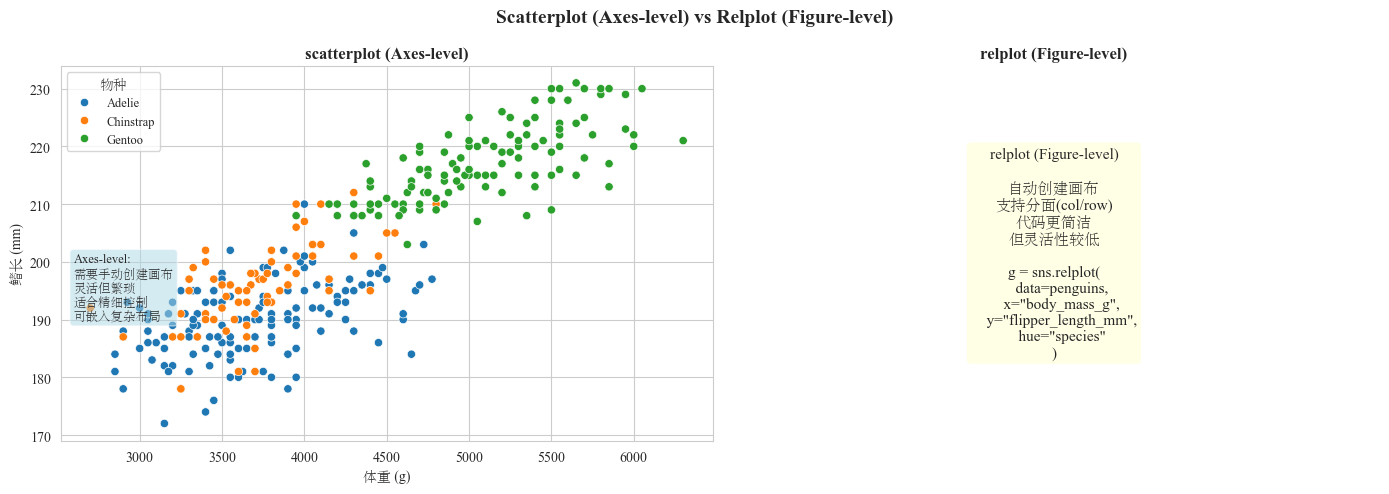

In [5]:
# ============================================================
# 额外演示：与relplot对比
# ============================================================
print("\n" + "=" * 60)  # 打印空行+60个等号分隔线
print("Scatterplot vs Relplot对比")  # 打印对比标题
print("=" * 60)  # 打印60个等号分隔线

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))  # 创建1行2列子图网格,figsize=(宽14英寸,高5英寸)横向布局
fig3.suptitle('Scatterplot (Axes-level) vs Relplot (Figure-level)',  # 主标题:对比两种接口级别
              fontsize=14,  # 标题字体大小14pt
              fontweight='bold')  # 标题粗体显示

# 左图：使用scatterplot
ax = axes3[0]  # 获取第1行第1列子图(索引0)
sns.scatterplot(data=penguins,  # 数据集:企鹅数据
                x='body_mass_g',  # X轴变量:体重(克)
                y='flipper_length_mm',  # Y轴变量:鳍长(毫米)
                hue='species',  # 颜色分组:按物种类别自动分配颜色
                ax=ax)  # 指定绘制在左子图
ax.set_title('scatterplot (Axes-level)', fontsize=12, fontweight='bold')  # 左图标题:12pt粗体,标注接口级别
ax.set_xlabel('体重 (g)')  # X轴标签:体重(克),默认字体大小
ax.set_ylabel('鳍长 (mm)')  # Y轴标签:鳍长(毫米),默认字体大小
sns.move_legend(ax, loc='upper left', fontsize=9, title='物种')  # 移动图例:左上角,9pt字体,标题"物种"

# 添加Axes-level特点说明:位置(左2%,中50%),9pt字体,浅蓝色半透明圆角背景框
ax.text(0.02,  # 水平位置:距离左边2%(0-1相对值)
        0.50,  # 垂直位置:中部50%
        'Axes-level:\n需要手动创建画布\n灵活但繁琐\n适合精细控制\n可嵌入复杂布局',  # 多行文本:详细列出5大特点
        transform=ax.transAxes,  # 坐标变换:使用Axes相对坐标系(0-1范围)
        fontsize=9,  # 文本字体大小9pt
        verticalalignment='top',  # 垂直对齐:文本顶部与指定位置对齐
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 背景框:圆角样式,浅蓝色填充,50%透明度

# 右图：说明relplot的特点
ax = axes3[1]  # 获取第1行第2列子图(索引1)
ax.text(  # 在右子图添加说明文本(不绘制图形)
    0.5,  # 水平位置:中心50%(0-1相对值)
    0.5,  # 垂直位置:中心50%(0-1相对值)
    'relplot (Figure-level)\n\n自动创建画布\n支持分面(col/row)\n代码更简洁\n但灵活性较低\n\n' +  # 多行文本:特点说明+代码示例
    'g = sns.relplot(\n' +  # 代码示例第1行:函数调用
    '    data=penguins,\n' +  # 代码示例第2行:数据集参数
    '    x="body_mass_g",\n' +  # 代码示例第3行:X轴参数
    '    y="flipper_length_mm",\n' +  # 代码示例第4行:Y轴参数
    '    hue="species"\n' +  # 代码示例第5行:hue参数
    ')',  # 代码示例第6行:闭合括号
    transform=ax.transAxes,  # 坐标变换:Axes相对坐标系
    fontsize=11,  # 文本字体大小11pt(稍大突出显示)
    ha='center',  # 水平对齐:水平居中
    va='center',  # 垂直对齐:垂直居中
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))  # 背景框:圆角样式,浅黄色填充,80%透明度(更明显)
ax.set_title('relplot (Figure-level)', fontsize=12, fontweight='bold')  # 右图标题:12pt粗体,标注接口级别
ax.axis('off')  # 关闭坐标轴:不显示X/Y轴刻度线和标签(纯文本说明图)

plt.tight_layout()  # 自动调整:优化左右子图间距,防止标题/文本重叠
plt.savefig('./scatters3.pdf', dpi=300,  # 保存为PDF:300dpi高分辨率
            bbox_inches='tight',  # 边界框:紧凑裁剪去除多余空白
            pad_inches=0.1)  # 边距:0.1英寸周围留白
plt.show()  # 显示完整对比图形窗口

In [6]:
# ============================================================
# 打印重要参数总结
# ============================================================
print("\n" + "="*60)
print("Seaborn scatterplot 核心参数总结 (v0.13.2+)")
print("="*60)
print("""
1. 基础参数:
   - data: 数据源(DataFrame)
   - x, y: 两个数值变量(必需)
   - hue: 颜色映射变量
     * 分类: 不同颜色
     * 连续: 渐变色
   - size: 大小映射变量
     * sizes=(min, max): 大小范围
   - style: 样式映射变量
     * 映射到点形状

2. 样式参数:
   - palette: 调色板
   - markers: 自定义标记形状列表
   - s: 固定点大小(默认约20)
   - alpha: 透明度(0-1)
   - edgecolor: 点边框颜色
   - linewidth: 边框宽度

3. 顺序控制:
   - hue_order: hue变量顺序
   - size_order: size变量顺序
   - style_order: style变量顺序

4. 图例控制:
   - legend: 图例显示
     * 'auto'(默认)
     * 'brief': 简化
     * 'full': 完整
     * False: 隐藏

5. 其他参数:
   - ax: 指定绘图的axes对象
   - hue_norm: 颜色归一化
   - size_norm: 大小归一化

6. 多维映射: ⭐⭐⭐
   - X + Y: 基础2维
   - X + Y + hue: 3维(颜色)
   - X + Y + hue + size: 4维(颜色+大小)
   - X + Y + hue + size + style: 5维(颜色+大小+形状)

7. Scatterplot vs Relplot: ⭐⭐⭐
   ┌─────────────┬────────────────┬────────────────┐
   │  特性       │  scatterplot   │  relplot       │
   │             │  (Axes-level)  │  (Figure-level)│
   ├─────────────┼────────────────┼────────────────┤
   │  创建画布   │  需手动创建    │  自动创建      │
   │  分面功能   │  需手动循环    │  内置col/row   │
   │  灵活性     │  更高 ⭐       │  较低          │
   │  易用性     │  需更多代码    │  更简单        │
   │  嵌入布局   │  可以 ⭐       │  不行          │
   │  适用场景   │  精细控制      │  快速探索      │
   └─────────────┴────────────────┴────────────────┘

8. 使用场景: ⭐⭐⭐
   ✓ 探索两变量关系
   ✓ 检查线性相关性
   ✓ 多维度数据可视化
   ✓ 识别聚类和模式
   ✓ 发现异常值
   ✓ 分组对比分析

9. 常用组合技巧:
   - scatter + hue: 分组散点
   - scatter + hue + size: 气泡图
   - scatter + regplot: 散点+回归线
   - scatter + annotate: 标注特殊点
   - scatter + axvline/axhline: 添加参考线

10. 气泡图制作: ⭐⭐⭐
    气泡图 = 散点图 + size映射
    - hue: 颜色表示类别
    - size: 大小表示数值
    - 适合展示3-4维数据

11. 最佳实践:
    ⭐ 选择合适的s或sizes
    ⭐ 大数据集降低alpha
    ⭐ 使用edgecolor增强辨识度
    ⭐ 多维映射不超过5维
    ⭐ 添加图例说明
    ⭐ 注意颜色对比度

12. 与relplot的选择:
    - 需要精细控制 → scatterplot
    - 需要分面(col/row) → relplot
    - 嵌入复杂布局 → scatterplot ⭐
    - 快速探索 → relplot
    - 组合多个图表 → scatterplot ⭐

13. 典型工作流:
    1. 基础散点图(x, y)
    2. 添加hue分组
    3. 考虑size/style增加维度
    4. 调整样式(alpha, edgecolor)
    5. 添加图例和标注
    6. 完成可视化

14. 注意事项:
    ⚠ scatterplot需要手动创建figure和axes
    ⚠ 多维映射不要过度使用
    ⚠ 注意点的大小和透明度
    ⚠ 连续型hue需要合适的palette
    ⚠ 大数据集考虑hexbin或kde

15. 优化建议:
    - 数据量>1000: 降低alpha或使用hexbin
    - 点重叠严重: 调整alpha和s
    - 多组对比: 使用hue + style
    - 展示第三维: 使用size
    - 需要回归线: 组合regplot
""")


Seaborn scatterplot 核心参数总结 (v0.13.2+)

1. 基础参数:
   - data: 数据源(DataFrame)
   - x, y: 两个数值变量(必需)
   - hue: 颜色映射变量
     * 分类: 不同颜色
     * 连续: 渐变色
   - size: 大小映射变量
     * sizes=(min, max): 大小范围
   - style: 样式映射变量
     * 映射到点形状

2. 样式参数:
   - palette: 调色板
   - markers: 自定义标记形状列表
   - s: 固定点大小(默认约20)
   - alpha: 透明度(0-1)
   - edgecolor: 点边框颜色
   - linewidth: 边框宽度

3. 顺序控制:
   - hue_order: hue变量顺序
   - size_order: size变量顺序
   - style_order: style变量顺序

4. 图例控制:
   - legend: 图例显示
     * 'auto'(默认)
     * 'brief': 简化
     * 'full': 完整
     * False: 隐藏

5. 其他参数:
   - ax: 指定绘图的axes对象
   - hue_norm: 颜色归一化
   - size_norm: 大小归一化

6. 多维映射: ⭐⭐⭐
   - X + Y: 基础2维
   - X + Y + hue: 3维(颜色)
   - X + Y + hue + size: 4维(颜色+大小)
   - X + Y + hue + size + style: 5维(颜色+大小+形状)

7. Scatterplot vs Relplot: ⭐⭐⭐
   ┌─────────────┬────────────────┬────────────────┐
   │  特性       │  scatterplot   │  relplot       │
   │             │  (Axes-level)  │  (Figure-level)│
   ├─────────────┼────────────────┼──────────────

## line

In [7]:
import seaborn as sns  # 导入seaborn:统计可视化库,基于matplotlib的高级接口
import matplotlib.pyplot as plt  # 导入matplotlib.pyplot:基础绘图库,创建和管理图形
import pandas as pd  # 导入pandas:数据处理库,DataFrame操作和CSV读写
import numpy as np  # 导入numpy:数值计算库,随机数生成和数组操作

# 设置中文字体和样式
sns.set_style("whitegrid")  # 设置seaborn绘图风格:whitegrid=白色背景+网格线,适合线图阅读
plt.rcParams['font.family'] = ['Times New Roman', 'STsong'
                               ]  # 设置全局字体:优先Times New Roman(英文),备选STsong(中文字体)
plt.rcParams[
    'axes.unicode_minus'] = False  # 禁用负号Unicode显示:防止负号显示为方块,确保证负号正常显示为'-'

# 准备数据集
# 使用flights数据集（航班乘客数量时间序列）
flights = sns.load_dataset(
    'flights'
)  # 从seaborn加载内置flights数据集:1949-1960年月度乘客数(144行,4列:year/month/passengers)

# 使用fmri数据集（功能性磁共振成像数据）
fmri = sns.load_dataset('fmri')  # 从seaborn加载内置fmri数据集:脑成像实验数据(区域/时间/事件/信号强度)

# 创建自定义数据集用于更多示例
np.random.seed(42)  # 设置随机种子:42确保结果可重现,每次运行生成相同随机数
months = [  # 定义12个月份缩写列表:用于生成时间序列数据
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct',
    'Nov', 'Dec'
]
custom_data = pd.DataFrame({  # 创建自定义DataFrame:3年销售数据(36行,4列)
    'month':
    months * 3,  # month列:12个月份重复3年(Jan-Dec x 3)
    'sales':
    np.random.randint(100, 500, 36) +
    np.array([i * 10 for i in range(12)] * 3),  # sales列:随机100-500+趋势(i*10重复3年)
    'category': ['Electronics'] * 12 + ['Clothing'] * 12 +
    ['Food'] * 12,  # category列:每12行一种类别(电子/服装/食品)
    'region': ['North'] * 4 + ['South'] * 4 + ['East'] * 4 +
    ['North'] * 4 +  # region列:每4个月循环3个地区(N/S/E),重复3年
    ['South'] * 4 + ['East'] * 4 + ['North'] * 4 + ['South'] * 4 + ['East'] * 4
})
custom_data.to_csv('./data/lineplot_data.csv',
                   encoding='utf-8')  # 保存CSV:路径./data/,UTF-8编码支持中文
custom_data = pd.read_csv('./data/lineplot_data.csv',
                          encoding='utf-8')  # 重新读取CSV:确保数据格式一致,UTF-8编码

# 使用flights数据集，按年份统计平均乘客数
yearly_data = flights.groupby('year')['passengers'].mean().reset_index(
)  # groupby年份->计算乘客数均值->reset_index转为普通DataFrame

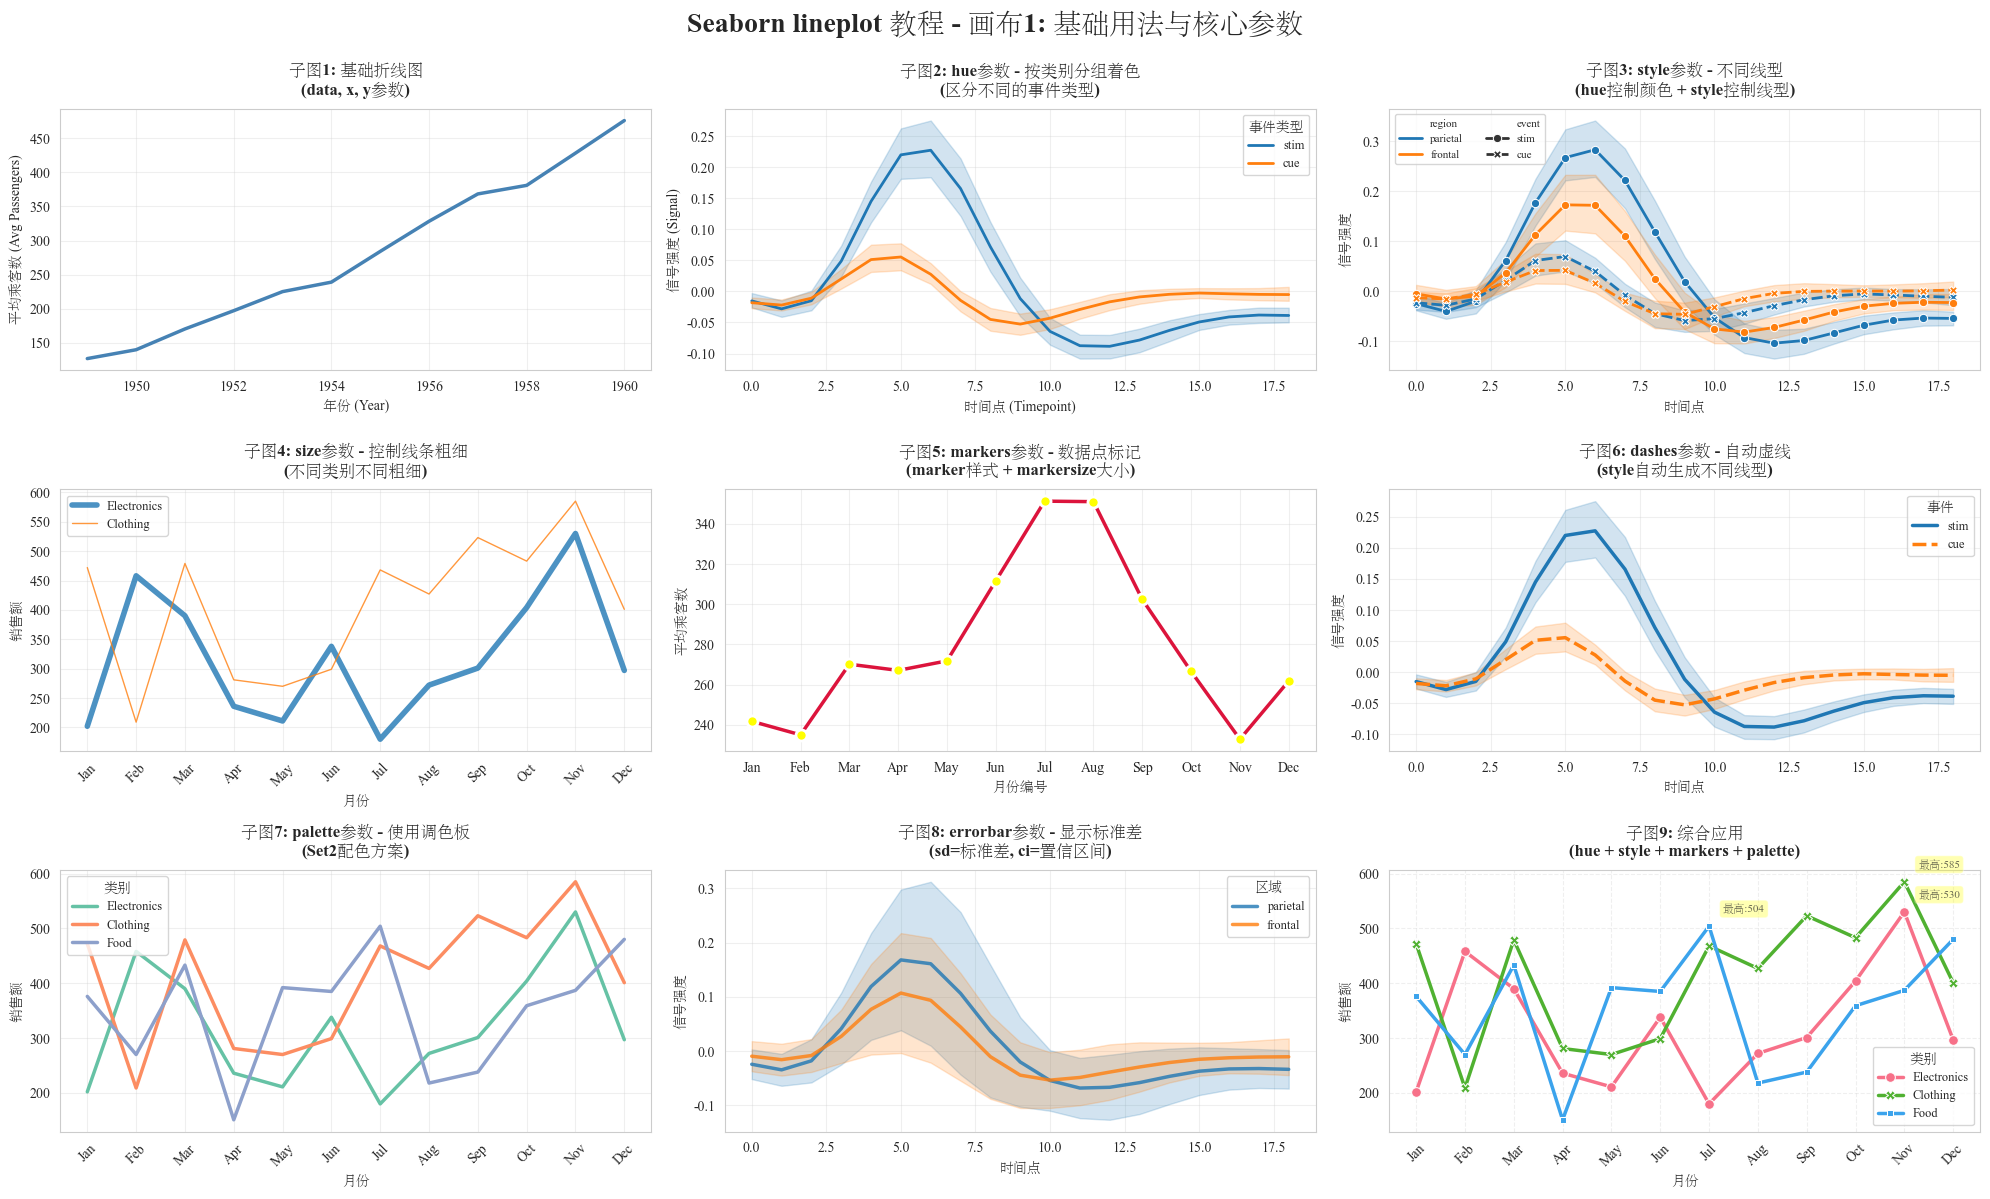

In [10]:
# ==================== 画布 1: 基础用法与核心参数 ====================
fig1 = plt.figure(figsize=(20, 12))  # 创建新图形窗口:宽20英寸,高12英寸,适合3x3复杂布局
fig1.suptitle('Seaborn lineplot 教程 - 画布1: 基础用法与核心参数',  # 主标题:覆盖所有子图
              fontsize=20,  # 标题字体大小:20pt(大标题突出)
              fontweight='bold',  # 标题粗体显示
              y=0.995)  # 标题垂直位置:距离顶部0.5%(0-1相对值)

# ========== 子图 1：基础折线图 - 最简单的用法 ==========
ax1 = plt.subplot(3, 3, 1)  # 创建第1个子图:3x3布局的第1个位置(索引从1开始)
sns.lineplot(data=yearly_data,  # 数据集:按年份聚合的乘客数据
             x='year',  # X轴变量:年份(1949-1960)
             y='passengers',  # Y轴变量:平均乘客数
             ax=ax1,  # 指定绘制在ax1子图
             linewidth=2.5,  # 线条宽度:2.5pt(较粗突出显示)
             color='steelblue')  # 线条颜色:steelblue(钢蓝色)
ax1.set_title('子图1: 基础折线图\n(data, x, y参数)',  # 子图标题:12pt粗体,含\n换行显示两行
              fontsize=12,
              fontweight='bold',
              pad=10)  # 标题与图形间距:10pt
ax1.set_xlabel('年份 (Year)', fontsize=10)  # X轴标签:10pt字体,含英文
ax1.set_ylabel('平均乘客数 (Avg Passengers)', fontsize=10)  # Y轴标签:10pt
ax1.grid(True, alpha=0.3)  # 显示网格线:30%透明度(浅灰色)

# ========== 子图 2：使用hue参数 - 按类别着色 ==========
ax2 = plt.subplot(3, 3, 2)  # 创建第2个子图:3x3布局第2位置
sns.lineplot(data=fmri,  # 数据集:脑成像数据
             x='timepoint',  # X轴:时间点(1-16)
             y='signal',  # Y轴:信号强度
             hue='event',  # 颜色分组:按事件类型(stim/dark)自动分配颜色
             ax=ax2,  # 指定子图
             linewidth=2)  # 线宽:2pt
ax2.set_title('子图2: hue参数 - 按类别分组着色\n(区分不同的事件类型)',  # 标题说明hue作用
              fontsize=12,
              fontweight='bold',
              pad=10)
ax2.set_xlabel('时间点 (Timepoint)', fontsize=10)
ax2.set_ylabel('信号强度 (Signal)', fontsize=10)
ax2.legend(title='事件类型', loc='upper right', fontsize=9)  # 图例:右上角,9pt字体,标题"事件类型"
ax2.grid(True, alpha=0.3)

# ========== 子图 3：使用style参数 - 不同线型 ==========
ax3 = plt.subplot(3, 3, 3)  # 创建第3个子图
sns.lineplot(data=fmri,
             x='timepoint',
             y='signal',
             hue='region',  # 颜色分组:按脑区(4个区域)
             style='event',  # 线型分组:按事件(实线/虚线)
             ax=ax3,
             linewidth=2,
             markers=True,  # 显示数据点标记
             markersize=6)  # 标记大小:6pt
ax3.set_title('子图3: style参数 - 不同线型\n(hue控制颜色 + style控制线型)', fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel('时间点', fontsize=10)
ax3.set_ylabel('信号强度', fontsize=10)
ax3.legend(loc='upper left', fontsize=8, ncol=2)  # 图例:左上角,8pt,2列布局(紧凑)
ax3.grid(True, alpha=0.3)

# ========== 子图 4：使用size参数 - 线条粗细 ==========
ax4 = plt.subplot(3, 3, 4)  # 创建第4个子图
size_data = custom_data[custom_data['category'].isin(['Electronics', 'Clothing'])]  # 筛选数据:仅电子+服装2类(24行)
sns.lineplot(data=size_data,
             x='month',  # X轴:月份(Jan-Dec)
             y='sales',  # Y轴:销售额
             hue='category',  # 颜色:按类别
             size='category',  # 线宽分组:按类别分配不同粗细
             sizes=(1, 4),  # 线宽范围:最小1pt,最大4pt
             ax=ax4,
             alpha=0.8)  # 透明度:80%不透明
ax4.set_title('子图4: size参数 - 控制线条粗细\n(不同类别不同粗细)', fontsize=12, fontweight='bold', pad=10)
ax4.set_xlabel('月份', fontsize=10)
ax4.set_ylabel('销售额', fontsize=10)
ax4.tick_params(axis='x', rotation=45)  # X轴标签:45度旋转(避免月份重叠)
ax4.legend(loc='upper left', fontsize=9)
ax4.grid(True, alpha=0.3)

# ========== 子图 5：markers参数 - 添加数据点标记 ==========
ax5 = plt.subplot(3, 3, 5)  # 创建第5个子图
monthly_avg = flights.groupby('month', observed=True)['passengers'].mean().reset_index()  # 按月聚合:计算12个月平均乘客数
sns.lineplot(data=monthly_avg,
             x='month',  # X轴:月份名称(Jan-Dec)
             y='passengers',
             ax=ax5,
             markers=True,  # 显示标记点
             marker='o',  # 标记形状:圆圈'o'
             markersize=8,  # 标记大小:8pt
             linewidth=2.5,  # 线宽:2.5pt
             color='crimson',  # 线条颜色:深红色
             markerfacecolor='yellow',  # 标记填充色:黄色
             markeredgewidth=2)  # 标记边框宽度:2pt
ax5.set_title('子图5: markers参数 - 数据点标记\n(marker样式 + markersize大小)', fontsize=12, fontweight='bold', pad=10)
ax5.set_xlabel('月份编号', fontsize=10)
ax5.set_ylabel('平均乘客数', fontsize=10)
ax5.grid(True, alpha=0.3)

# ========== 子图 6：dashes参数 - 自定义虚线样式 ==========
ax6 = plt.subplot(3, 3, 6)
sns.lineplot(data=fmri,
             x='timepoint',
             y='signal',
             hue='event',
             style='event',  # 线型分组
             dashes=True,  # 启用虚线:自动为不同style生成虚线样式
             ax=ax6,
             linewidth=2.5)
ax6.set_title('子图6: dashes参数 - 自动虚线\n(style自动生成不同线型)', fontsize=12, fontweight='bold', pad=10)
ax6.set_xlabel('时间点', fontsize=10)
ax6.set_ylabel('信号强度', fontsize=10)
ax6.legend(title='事件', fontsize=9)
ax6.grid(True, alpha=0.3)

# ========== 子图 7：palette参数 - 调色板选择 ==========
ax7 = plt.subplot(3, 3, 7)
sns.lineplot(data=custom_data,
             x='month',
             y='sales',
             hue='category',  # 颜色分组:3个类别
             palette='Set2',  # 调色板:Set2(8色柔和配色方案)
             ax=ax7,
             linewidth=2.5,
             markers=True,
             markersize=6)
ax7.set_title('子图7: palette参数 - 使用调色板\n(Set2配色方案)', fontsize=12, fontweight='bold', pad=10)
ax7.set_xlabel('月份', fontsize=10)
ax7.set_ylabel('销售额', fontsize=10)
ax7.tick_params(axis='x', rotation=45)  # X轴旋转45度
ax7.legend(title='类别', loc='upper left', fontsize=9)
ax7.grid(True, alpha=0.3)

# ========== 子图 8：errorbar参数 - 误差带/置信区间 ==========
ax8 = plt.subplot(3, 3, 8)
sns.lineplot(data=fmri,
             x='timepoint',
             y='signal',
             hue='region',  # 按脑区分组
             errorbar='sd',  # 误差带:sd=标准差(显示数据变异性)
             ax=ax8,
             linewidth=2.5,
             alpha=0.8)
ax8.set_title('子图8: errorbar参数 - 显示标准差\n(sd=标准差, ci=置信区间)', fontsize=12, fontweight='bold', pad=10)
ax8.set_xlabel('时间点', fontsize=10)
ax8.set_ylabel('信号强度', fontsize=10)
ax8.legend(title='区域', fontsize=9)
ax8.grid(True, alpha=0.3)

# ========== 子图 9：综合应用 - 多参数组合 ==========
ax9 = plt.subplot(3, 3, 9)
sns.lineplot(data=custom_data,
             x='month',
             y='sales',
             hue='category',  # 颜色分组
             style='category',  # 线型分组
             markers=True,  # 显示标记
             markersize=7,  # 标记大小7pt
             linewidth=2.5,
             palette='husl',  # 调色板:husl(高饱和度均匀色相)
             dashes=False,  # 禁用虚线(纯实线)
             ax=ax9)
ax9.set_title('子图9: 综合应用\n(hue + style + markers + palette)', fontsize=12, fontweight='bold', pad=10)
ax9.set_xlabel('月份', fontsize=10)
ax9.set_ylabel('销售额', fontsize=10)
ax9.tick_params(axis='x', rotation=45)
ax9.legend(title='类别', loc='best', fontsize=9)  # 图例自动最佳位置
ax9.grid(True, alpha=0.3, linestyle='--')  # 网格线:虚线样式

# 添加最大值标注:每个类别标注最高销售额
max_idx = custom_data.groupby('category')['sales'].idxmax()  # 按类别找最大值索引
for cat in custom_data['category'].unique():  # 循环3个类别
    max_row = custom_data.loc[max_idx[cat]]  # 获取最大值行数据
    ax9.annotate(f'最高:{max_row["sales"]}',  # 标注文字:最高值+数值
                 xy=(max_row.name % 12, max_row['sales']),  # 指向坐标:(月份索引%12,销售额)
                 xytext=(10, 10),  # 文字偏移:右上10点位置
                 textcoords='offset points',  # 偏移单位:点(pt)
                 fontsize=8,  # 标注字体:8pt
                 alpha=0.7,  # 透明度:70%
                 bbox=dict(boxstyle='round,pad=0.3',  # 背景框:圆角,内边距0.3
                           facecolor='yellow',  # 黄色背景
                           alpha=0.3))  # 背景透明度30%

plt.tight_layout()  # 自动调整:优化9个子图间距,防止重叠
plt.show()  # 显示完整3x3图形窗口

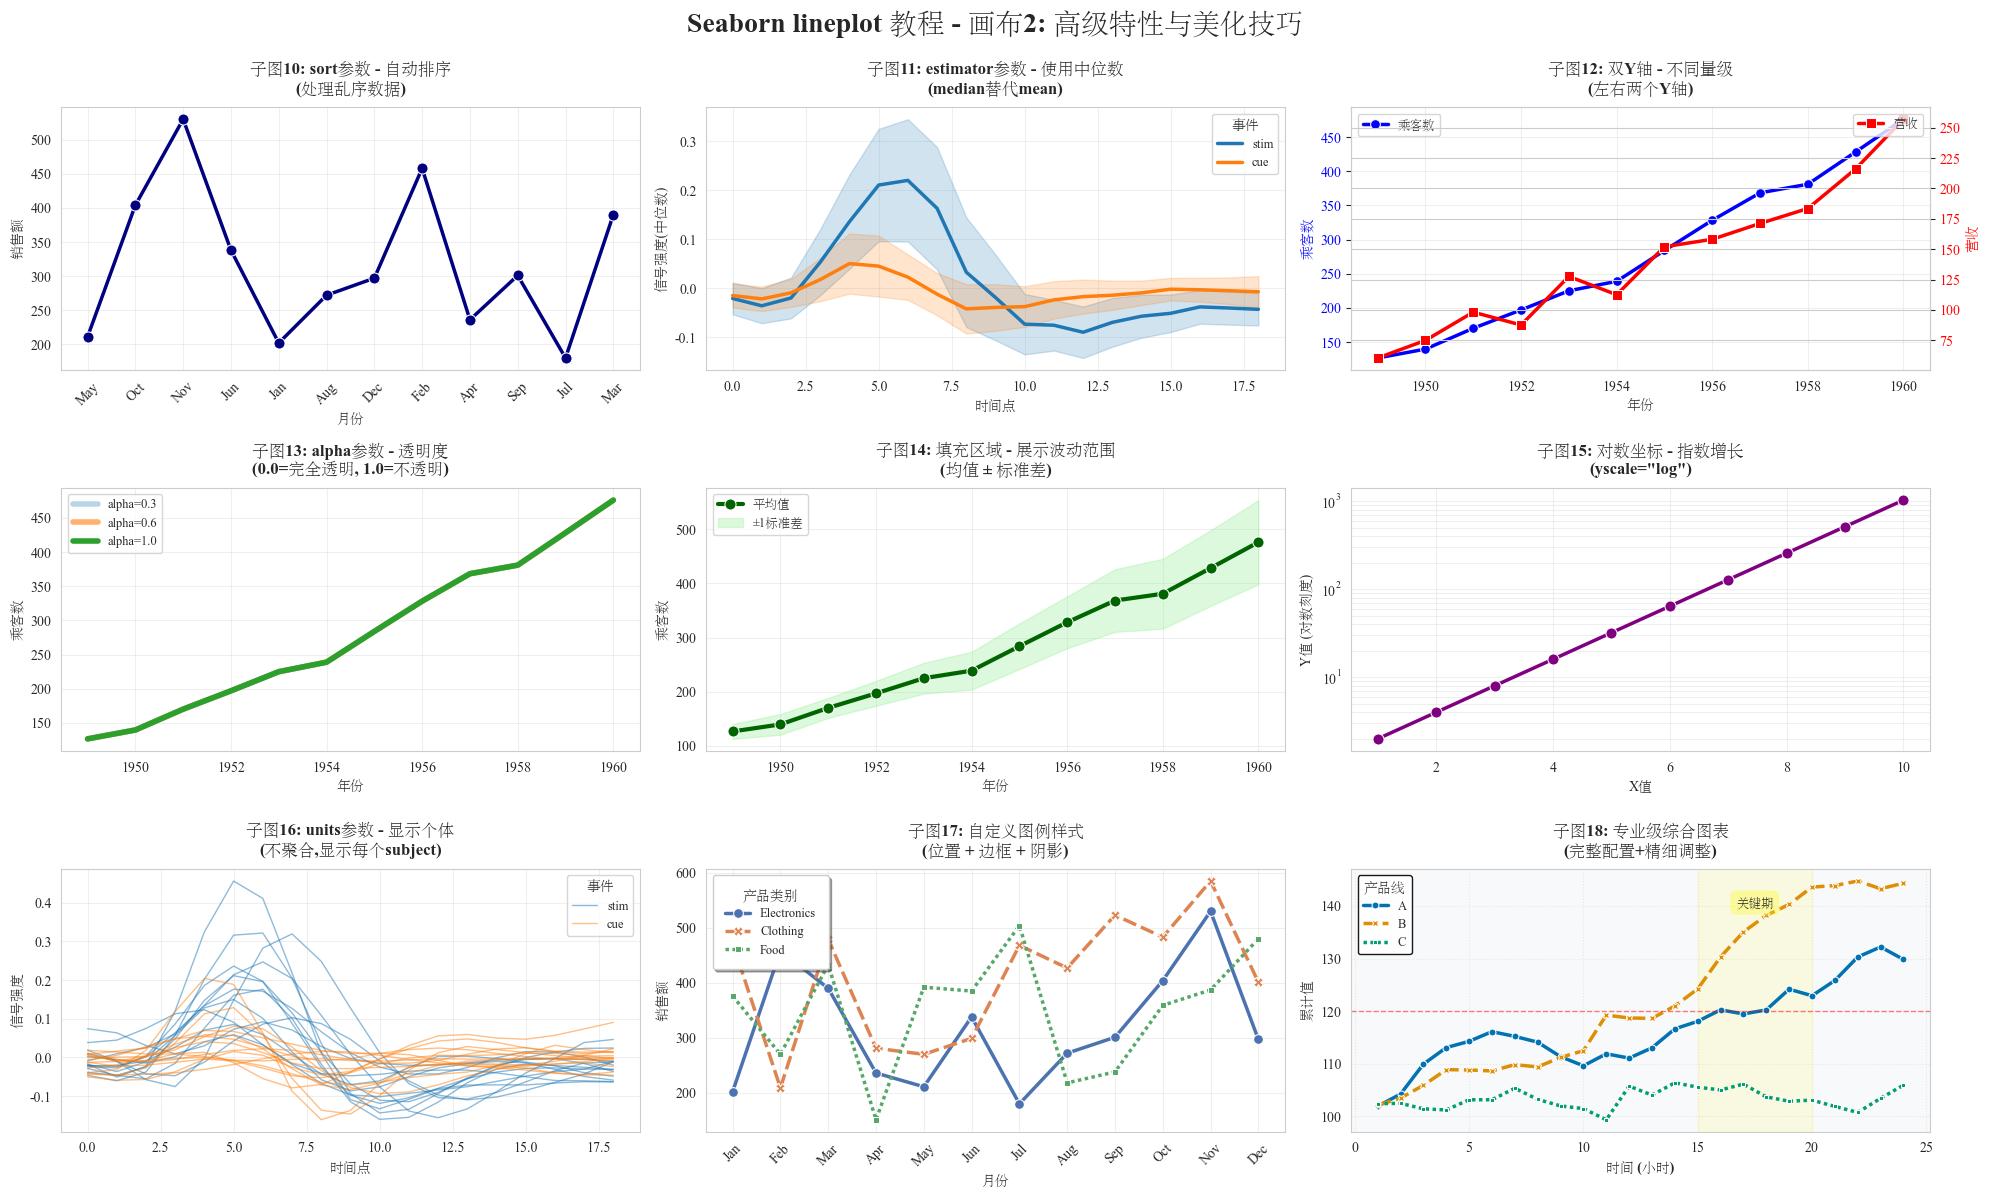

In [11]:
# ==================== 画布 2: 高级特性与美化技巧 ====================
fig2 = plt.figure(figsize=(20, 12))  # 创建新图形窗口:宽20英寸,高12英寸,3x3复杂布局
fig2.suptitle('Seaborn lineplot 教程 - 画布2: 高级特性与美化技巧',  # 主标题:覆盖所有子图
              fontsize=20,  # 标题字体大小:20pt(大标题突出)
              fontweight='bold',  # 标题粗体显示
              y=0.995)  # 标题垂直位置:距离顶部0.5%(0-1相对值)

# ========== 子图 10：sort参数 - 控制排序 ==========
ax10 = plt.subplot(3, 3, 1)  # 创建第1个子图:3x3布局第1位置
unsorted_data = custom_data.sample(frac=1)  # 随机打乱数据:frac=1表示100%随机采样,破坏原有月份顺序
sns.lineplot(data=unsorted_data[unsorted_data['category'] == 'Electronics'],  # 筛选电子类12行乱序数据
             x='month',  # X轴:月份(乱序)
             y='sales',
             ax=ax10,
             sort=True,  # 自动排序:按x轴值排序后绘图(月份顺序:Jan->Dec)
             linewidth=2.5,  # 线宽:2.5pt
             marker='o',  # 标记形状:圆圈
             markersize=8,  # 标记大小:8pt
             color='navy')  # 线条颜色:海军蓝
ax10.set_title('子图10: sort参数 - 自动排序\n(处理乱序数据)',  # 标题说明sort作用
               fontsize=12,
               fontweight='bold',
               pad=10)  # 标题间距:10pt
ax10.set_xlabel('月份', fontsize=10)
ax10.set_ylabel('销售额', fontsize=10)
ax10.tick_params(axis='x', rotation=45)  # X轴标签:45度旋转避免重叠
ax10.grid(True, alpha=0.3)  # 网格线:30%透明度

# ========== 子图 11：estimator参数 - 聚合函数 ==========
ax11 = plt.subplot(3, 3, 2)  # 创建第2个子图
sns.lineplot(data=fmri,  # 数据集:脑成像数据
             x='timepoint',
             y='signal',
             hue='event',  # 按事件着色
             estimator='median',  # 聚合函数:中位数(替代默认均值mean)
             errorbar='sd',  # 误差带:标准差
             ax=ax11,
             linewidth=2.5)
ax11.set_title('子图11: estimator参数 - 使用中位数\n(median替代mean)', fontsize=12, fontweight='bold', pad=10)
ax11.set_xlabel('时间点', fontsize=10)
ax11.set_ylabel('信号强度(中位数)', fontsize=10)  # Y标签标明使用中位数
ax11.legend(title='事件', fontsize=9)
ax11.grid(True, alpha=0.3)

# ========== 子图 12：双Y轴 - 不同量级数据 ==========
ax12 = plt.subplot(3, 3, 3)  # 创建第3个子图
ax12_twin = ax12.twinx()  # 创建右Y轴:与ax12共享X轴
# 主轴(左Y轴):乘客数
sns.lineplot(data=yearly_data,
             x='year',
             y='passengers',
             ax=ax12,  # 绘制在主轴
             linewidth=2.5,
             marker='o',  # 圆圈标记
             markersize=7,
             color='blue',
             label='乘客数')
# 次轴(右Y轴):模拟营收数据
revenue_data = yearly_data.copy()  # 复制年份数据
revenue_data['revenue'] = yearly_data['passengers'] * 0.5 + np.random.randint(-20, 20, len(yearly_data))  # 营收=乘客数*0.5+随机[-20,20]
sns.lineplot(data=revenue_data,
             x='year',
             y='revenue',
             ax=ax12_twin,  # 绘制在次轴
             linewidth=2.5,
             marker='s',  # 方块标记
             markersize=7,
             color='red',
             label='营收')
ax12.set_title('子图12: 双Y轴 - 不同量级\n(左右两个Y轴)', fontsize=12, fontweight='bold', pad=10)
ax12.set_xlabel('年份', fontsize=10)
ax12.set_ylabel('乘客数', fontsize=10, color='blue')  # 左Y标签:蓝色
ax12_twin.set_ylabel('营收', fontsize=10, color='red')  # 右Y标签:红色
ax12.tick_params(axis='y', labelcolor='blue')  # 左Y刻度:蓝色
ax12_twin.tick_params(axis='y', labelcolor='red')  # 右Y刻度:红色
ax12.legend(loc='upper left', fontsize=9)  # 主轴图例:左上
ax12_twin.legend(loc='upper right', fontsize=9)  # 次轴图例:右上
ax12.grid(True, alpha=0.3)

# ========== 子图 13：alpha参数 - 透明度控制 ==========
ax13 = plt.subplot(3, 3, 4)
for alpha_val in [0.3, 0.6, 1.0]:  # 循环3种透明度:30%/60%/100%
    sns.lineplot(data=yearly_data,
                 x='year',
                 y='passengers',
                 ax=ax13,
                 alpha=alpha_val,  # 透明度:0.0=完全透明,1.0=不透明
                 linewidth=4,  # 加粗线条:4pt便于比较透明度
                 label=f'alpha={alpha_val}')  # 图例标签:显示具体alpha值
ax13.set_title('子图13: alpha参数 - 透明度\n(0.0=完全透明, 1.0=不透明)', fontsize=12, fontweight='bold', pad=10)
ax13.set_xlabel('年份', fontsize=10)
ax13.set_ylabel('乘客数', fontsize=10)
ax13.legend(fontsize=9)
ax13.grid(True, alpha=0.3)

# ========== 子图 14：填充区域 - fill_between效果 ==========
ax14 = plt.subplot(3, 3, 5)
time_series = flights.groupby('year').agg({'passengers': ['mean', 'std']}).reset_index()  # 按年聚合:计算均值+标准差
time_series.columns = ['year', 'mean', 'std']  # 重命名列:year/mean/std
sns.lineplot(data=time_series,
             x='year',
             y='mean',  # 绘制均值线
             ax=ax14,
             linewidth=3,
             marker='o',
             markersize=8,
             color='darkgreen',
             label='平均值')
ax14.fill_between(time_series['year'],  # X坐标:年份
                  time_series['mean'] - time_series['std'],  # 下边界:均值-标准差
                  time_series['mean'] + time_series['std'],  # 上边界:均值+标准差
                  alpha=0.3,  # 填充透明度:30%
                  color='lightgreen',  # 填充颜色:浅绿色
                  label='±1标准差')  # 图例标签
ax14.set_title('子图14: 填充区域 - 展示波动范围\n(均值 ± 标准差)', fontsize=12, fontweight='bold', pad=10)
ax14.set_xlabel('年份', fontsize=10)
ax14.set_ylabel('乘客数', fontsize=10)
ax14.legend(fontsize=9)
ax14.grid(True, alpha=0.3)

# ========== 子图 15：对数坐标 - 处理指数增长 ==========
ax15 = plt.subplot(3, 3, 6)
exp_data = pd.DataFrame({'x': range(1, 11), 'y': [2**i for i in range(1, 11)]})  # 创建指数数据:x=1-10,y=2^1到2^10
sns.lineplot(data=exp_data,
             x='x',
             y='y',
             ax=ax15,
             linewidth=2.5,
             marker='o',
             markersize=8,
             color='purple')
ax15.set_yscale('log')  # Y轴对数刻度:将指数增长转为线性显示
ax15.set_title('子图15: 对数坐标 - 指数增长\n(yscale="log")', fontsize=12, fontweight='bold', pad=10)
ax15.set_xlabel('X值', fontsize=10)
ax15.set_ylabel('Y值 (对数刻度)', fontsize=10)  # Y标签说明对数刻度
ax15.grid(True, alpha=0.3, which='both')  # 网格线:主刻度+次刻度

# ========== 子图 16：多子类别 - units参数 ==========
ax16 = plt.subplot(3, 3, 7)
sns.lineplot(data=fmri[fmri['region'] == 'frontal'],  # 筛选额叶区域数据
             x='timepoint',
             y='signal',
             hue='event',
             units='subject',  # 个体标识:按subject分组(不聚合)
             estimator=None,  # 无聚合:显示所有个体轨迹
             ax=ax16,
             linewidth=1,  # 细线:1pt(多条线不拥挤)
             alpha=0.5)  # 半透明:50%便于观察重叠
ax16.set_title('子图16: units参数 - 显示个体\n(不聚合,显示每个subject)', fontsize=12, fontweight='bold', pad=10)
ax16.set_xlabel('时间点', fontsize=10)
ax16.set_ylabel('信号强度', fontsize=10)
ax16.legend(title='事件', fontsize=9)
ax16.grid(True, alpha=0.3)

# ========== 子图 17：自定义图例 - 位置与样式 ==========
ax17 = plt.subplot(3, 3, 8)
sns.lineplot(data=custom_data,
             x='month',
             y='sales',
             hue='category',
             style='category',
             linewidth=2.5,
             markers=True,
             markersize=7,
             palette='deep',  # 深色调色板
             ax=ax17)
ax17.set_title('子图17: 自定义图例样式\n(位置 + 边框 + 阴影)', fontsize=12, fontweight='bold', pad=10)
ax17.set_xlabel('月份', fontsize=10)
ax17.set_ylabel('销售额', fontsize=10)
ax17.tick_params(axis='x', rotation=45)
# 自定义图例:丰富样式
ax17.legend(title='产品类别',  # 图例标题
            loc='upper left',  # 位置:左上角
            fontsize=9,  # 字体:9pt
            frameon=True,  # 显示边框:True
            shadow=True,  # 添加阴影:True
            fancybox=True,  # 圆角边框:True
            title_fontsize=10,  # 标题字体:10pt
            ncol=1,  # 列数:1列
            borderpad=1)  # 边框内边距:1
ax17.grid(True, alpha=0.3)

# ========== 子图 18：终极综合 - 专业级图表 ==========
ax18 = plt.subplot(3, 3, 9)
# 创建趋势数据:3条产品线,24个时间点累计和
trend_data = pd.DataFrame({
    'time': list(range(1, 25)) * 3,  # 时间:1-24重复3次
    'value': np.concatenate([  # 累计值:3条随机游走轨迹+100基线
        np.cumsum(np.random.randn(24) * 2 + 1) + 100,  # 产品A:标准差2,趋势+1
        np.cumsum(np.random.randn(24) * 2 + 1.5) + 100,  # 产品B:趋势+1.5
        np.cumsum(np.random.randn(24) * 2 + 0.5) + 100  # 产品C:趋势+0.5
    ]),
    'product': ['A'] * 24 + ['B'] * 24 + ['C'] * 24  # 产品标签
})
sns.lineplot(data=trend_data,
             x='time',
             y='value',
             hue='product',  # 颜色分组
             style='product',  # 线型分组
             markers=True,
             markersize=5,
             linewidth=2.5,
             palette='colorblind',  # 色盲友好调色板
             errorbar=None,  # 无误差带
             ax=ax18)
# 专业美化
ax18.set_title('子图18: 专业级综合图表\n(完整配置+精细调整)', fontsize=12, fontweight='bold', pad=10)
ax18.set_xlabel('时间 (小时)', fontsize=10, fontweight='bold')  # X标签粗体
ax18.set_ylabel('累计值', fontsize=10, fontweight='bold')  # Y标签粗体
ax18.legend(title='产品线',  # 图例标题
            loc='upper left',
            fontsize=9,
            framealpha=0.9,  # 边框透明度:90%
            edgecolor='black')  # 边框颜色:黑色
ax18.grid(True, alpha=0.4, linestyle=':', linewidth=0.8)  # 网格:40%透明,点线,0.8pt
ax18.set_facecolor('#f8f9fa')  # 背景色:浅灰(#f8f9fa)
# 添加水平参考线:目标线
ax18.axhline(y=120,  # Y=120
             color='red',
             linestyle='--',  # 虚线
             linewidth=1,
             alpha=0.5,
             label='目标线')
# 添加阴影区域:关键区间15-20
ax18.axvspan(15, 20,  # X范围:15-20
             alpha=0.1,  # 透明度:10%
             color='yellow')  # 黄色阴影
ax18.text(17.5,  # X=17.5(区间中心)
          140,  # Y=140
          '关键期',  # 标注文字
          fontsize=9,
          ha='center',  # 水平居中
          bbox=dict(boxstyle='round,pad=0.5',  # 圆角框,内边距0.5
                    facecolor='yellow', alpha=0.3))  # 黄色30%透明背景

plt.tight_layout()  # 自动调整:优化9个子图间距
plt.show()  # 显示完整专业图形窗口

In [12]:
print("=" * 70)
print("📊 Seaborn lineplot 教程完成!")
print("=" * 70)
print("\n✅ 画布1覆盖内容:")
print("  • 基础用法: data, x, y参数")
print("  • hue参数: 按类别着色分组")
print("  • style参数: 不同线型样式")
print("  • size参数: 控制线条粗细")
print("  • markers参数: 添加数据点标记")
print("  • dashes参数: 自定义虚线样式")
print("  • palette参数: 选择调色板")
print("  • errorbar参数: 显示误差带/置信区间")
print("  • 综合应用: 多参数组合")
print("\n✅ 画布2覆盖内容:")
print("  • sort参数: 自动排序乱序数据")
print("  • estimator参数: 使用不同聚合函数")
print("  • 双Y轴: 不同量级数据可视化")
print("  • alpha参数: 透明度控制")
print("  • 填充区域: 展示数据波动范围")
print("  • 对数坐标: 处理指数增长数据")
print("  • units参数: 显示个体而非聚合")
print("  • 自定义图例: 位置与样式调整")
print("  • 专业级综合: 完整配置示例")
print("\n" + "=" * 70)
print("💡 学习建议:")
print("  1. 从简单到复杂,逐个参数理解")
print("  2. 尝试修改参数值,观察变化")
print("  3. 组合多个参数,创造自己的风格")
print("  4. 根据数据特点选择合适的可视化方式")
print("=" * 70)

📊 Seaborn lineplot 教程完成!

✅ 画布1覆盖内容:
  • 基础用法: data, x, y参数
  • hue参数: 按类别着色分组
  • style参数: 不同线型样式
  • size参数: 控制线条粗细
  • markers参数: 添加数据点标记
  • dashes参数: 自定义虚线样式
  • palette参数: 选择调色板
  • errorbar参数: 显示误差带/置信区间
  • 综合应用: 多参数组合

✅ 画布2覆盖内容:
  • sort参数: 自动排序乱序数据
  • estimator参数: 使用不同聚合函数
  • 双Y轴: 不同量级数据可视化
  • alpha参数: 透明度控制
  • 填充区域: 展示数据波动范围
  • 对数坐标: 处理指数增长数据
  • units参数: 显示个体而非聚合
  • 自定义图例: 位置与样式调整
  • 专业级综合: 完整配置示例

💡 学习建议:
  1. 从简单到复杂,逐个参数理解
  2. 尝试修改参数值,观察变化
  3. 组合多个参数,创造自己的风格
  4. 根据数据特点选择合适的可视化方式


## rel图表

In [13]:
import seaborn as sns  # 导入seaborn:统计可视化库,Figure-level接口(relplot)
import matplotlib.pyplot as plt  # 导入matplotlib.pyplot:基础绘图库,图形显示和保存
import pandas as pd  # 导入pandas:数据处理库,DataFrame操作和形状查询
import numpy as np  # 导入numpy:数值计算库(本例未直接使用,但预留)

# 加载数据集
penguins = sns.load_dataset('penguins').dropna()  # 加载企鹅数据集:333行,删除缺失值后约333行7列(物种/岛屿/喙长/喙深/鳍长/体重/性别)
tips = sns.load_dataset('tips')  # 加载小费数据集:244行,7列(账单/小费/性别/吸烟者/日期/时间/人数)
flights = sns.load_dataset('flights')  # 加载航班数据集:144行,4列(年份/月份/乘客数)

print("="*60)  # 打印60个等号:创建标题分隔线
print("Relplot: Seaborn的关系图大师")  # 打印主标题:突出relplot功能
print("="*60)  # 打印60个等号:结束标题分隔线
print(f"\nPenguins数据集: {penguins.shape}")  # 打印企鹅数据形状:格式化字符串f-string,(行数,列数)
print(f"Tips数据集: {tips.shape}")  # 打印小费数据形状:(244, 7)
print(f"Flights数据集: {flights.shape}")  # 打印航班数据形状:(144, 4)
print(f"\nRelplot特点:")  # 打印空行+特点标题
print("✓ Figure-level函数，自动创建画布")  # 特点1:Figure-level接口,无需手动plt.figure()
print("✓ 支持scatter和line两种类型")  # 特点2:kind参数可选'scatter'/'line'
print("✓ 多维度映射(hue/size/style)")  # 特点3:3维美学映射(颜色/大小/形状)
print("✓ 强大的分面功能(col/row)\n")  # 特点4:分面网格(col/row参数),空行结束

Relplot: Seaborn的关系图大师

Penguins数据集: (333, 7)
Tips数据集: (244, 7)
Flights数据集: (144, 3)

Relplot特点:
✓ Figure-level函数，自动创建画布
✓ 支持scatter和line两种类型
✓ 多维度映射(hue/size/style)
✓ 强大的分面功能(col/row)



画布 1: 两种基础图表类型 (kind参数)
------------------------------------------------------------


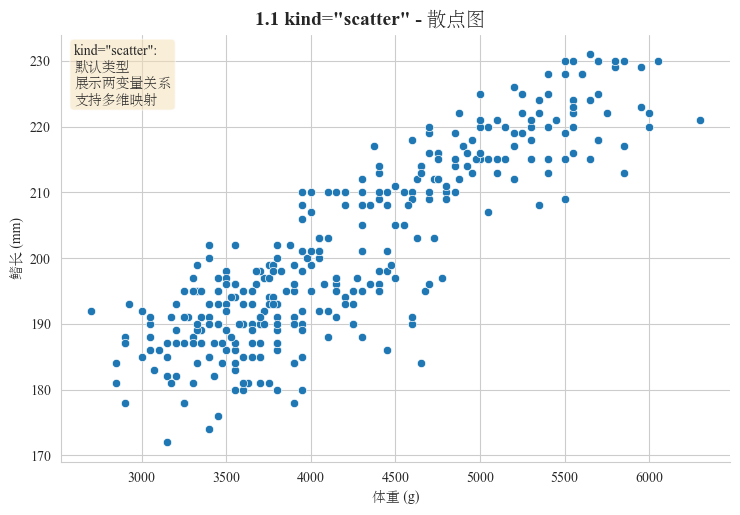

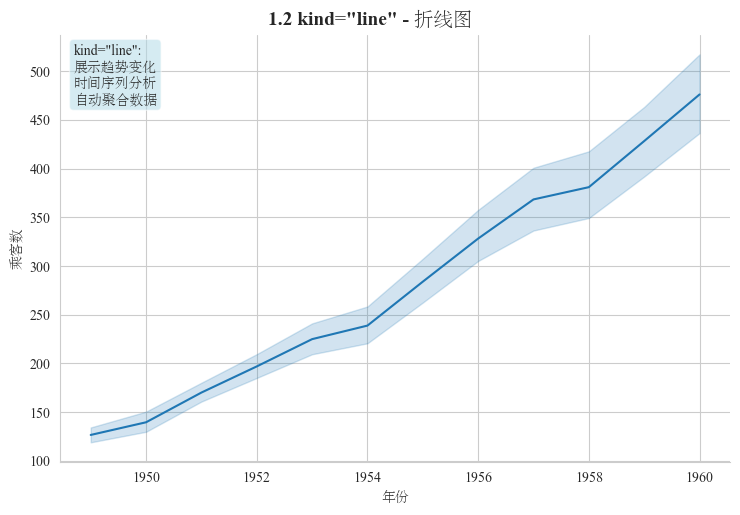

In [14]:
# ============================================================
# 画布 1: kind参数 - 两种基础类型
# ============================================================
print("画布 1: 两种基础图表类型 (kind参数)")  # 打印画布标题:说明当前画布主题
print("-" * 60)  # 打印60个连字符:分隔线(比等号细,用于子标题分隔)

# ========== 1.1 kind='scatter' ==========
g = sns.relplot(data=penguins,  # 数据集:企鹅数据(333行,7列)
                x='body_mass_g',  # X轴变量:体重(克),数值型
                y='flipper_length_mm',  # Y轴变量:鳍长(毫米),数值型
                kind='scatter',  # 图表类型:散点图(默认类型)
                height=5,  # 子图高度:5英寸(控制单个FacetGrid单元高度)
                aspect=1.5)  # 宽高比:1.5(宽度=高度*1.5=7.5英寸,横向矩形)
g.fig.suptitle('1.1 kind="scatter" - 散点图',  # 图形主标题:覆盖整个Figure
               fontsize=14,  # 标题字体:14pt
               fontweight='bold',  # 标题粗体
               y=1.02)  # 标题位置:上方1.02倍高度(略微上移避免重叠)
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 统一设置X/Y轴标签:所有分面共用
g.ax.text(0.02,  # 文本位置X:左边2%(0-1相对坐标)
          0.98,  # 文本位置Y:顶部2%(0-1相对坐标)
          'kind="scatter":\n默认类型\n展示两变量关系\n支持多维映射',  # 多行说明文本:\n换行
          transform=g.ax.transAxes,  # 坐标系:Axes相对坐标(0-1范围)
          fontsize=10,  # 文本字体:10pt
          verticalalignment='top',  # 垂直对齐:顶部对齐
          bbox=dict(boxstyle='round',  # 背景框样式:圆角
                    facecolor='wheat',  # 背景色:小麦色
                    alpha=0.5))  # 透明度:50%
plt.show()  # 显示第一个图形:单散点图(1x1分面)

# ========== 1.2 kind='line' ==========
g = sns.relplot(data=flights,  # 数据集:航班数据(144行,4列)
                x='year',  # X轴变量:年份(1949-1960),分类型
                y='passengers',  # Y轴变量:乘客数,数值型
                kind='line',  # 图表类型:折线图
                height=5,  # 子图高度:5英寸
                aspect=1.5)  # 宽高比:1.5(宽度7.5英寸)
g.fig.suptitle('1.2 kind="line" - 折线图',  # 主标题:说明折线图类型
            fontsize=14,  # 标题字体:14pt
            fontweight='bold',  # 标题粗体
            y=1.02)  # 标题位置:上方1.02倍
g.set_axis_labels('年份', '乘客数')  # X/Y轴标签:简洁中文
g.ax.text(0.02,  # 左2%位置
          0.98,  # 顶部2%位置
          'kind="line":\n展示趋势变化\n时间序列分析\n自动聚合数据',  # 折线图特点说明
          transform=g.ax.transAxes,  # Axes相对坐标系
          fontsize=10,  # 10pt字体
          verticalalignment='top',  # 顶部对齐
          bbox=dict(boxstyle='round',  # 圆角背景框
                    facecolor='lightblue',  # 浅蓝色背景
                    alpha=0.5))  # 50%透明度
plt.show()  # 显示第二个图形:单折线图(1x1分面)


画布 2: hue参数 - 颜色映射
------------------------------------------------------------


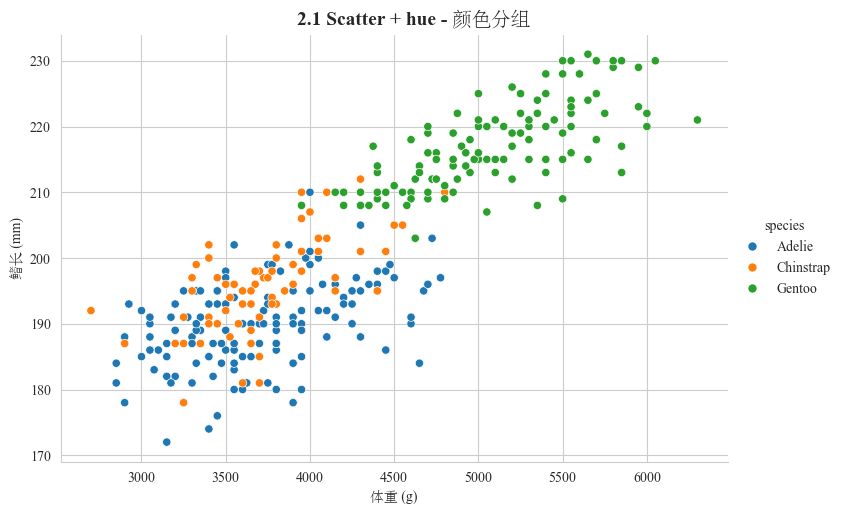

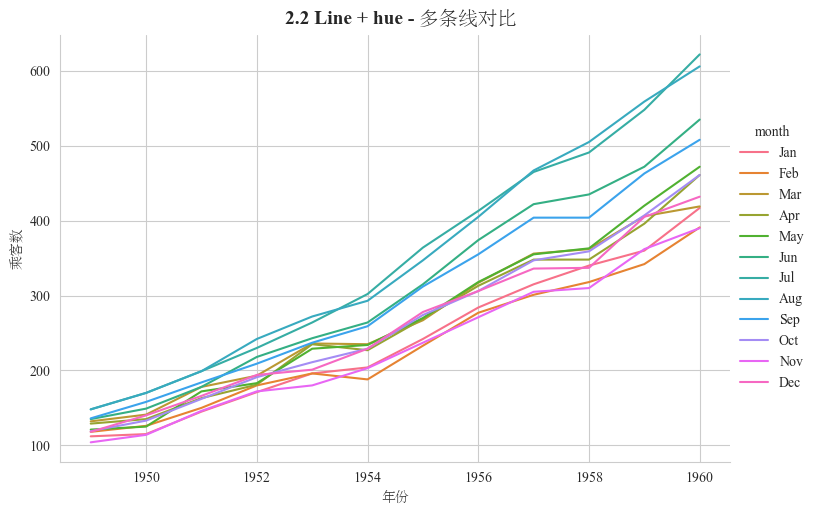

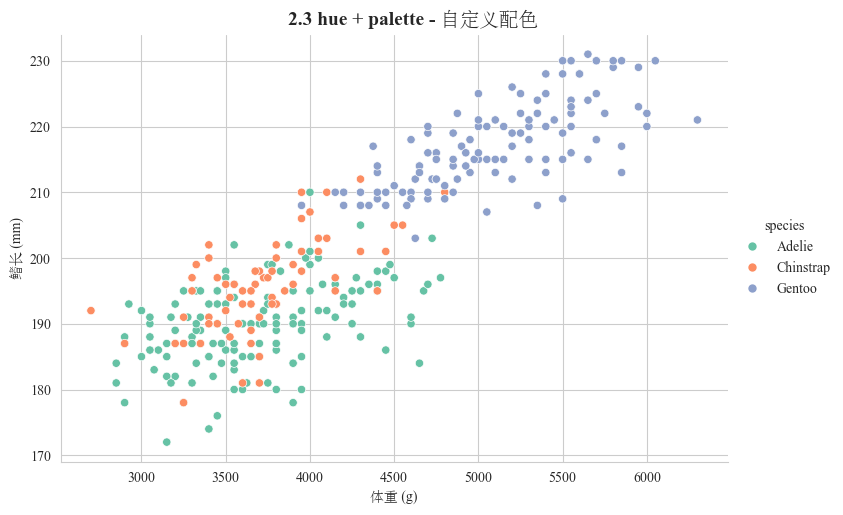

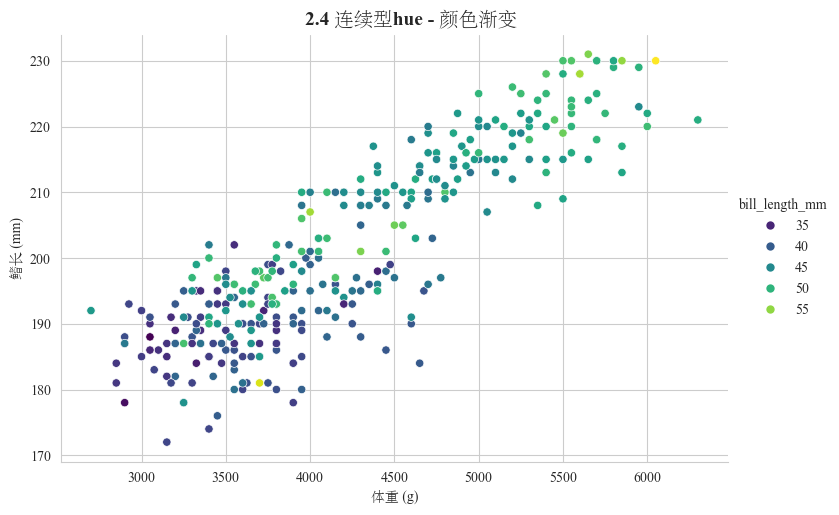


画布 3: size参数 - 大小映射
------------------------------------------------------------


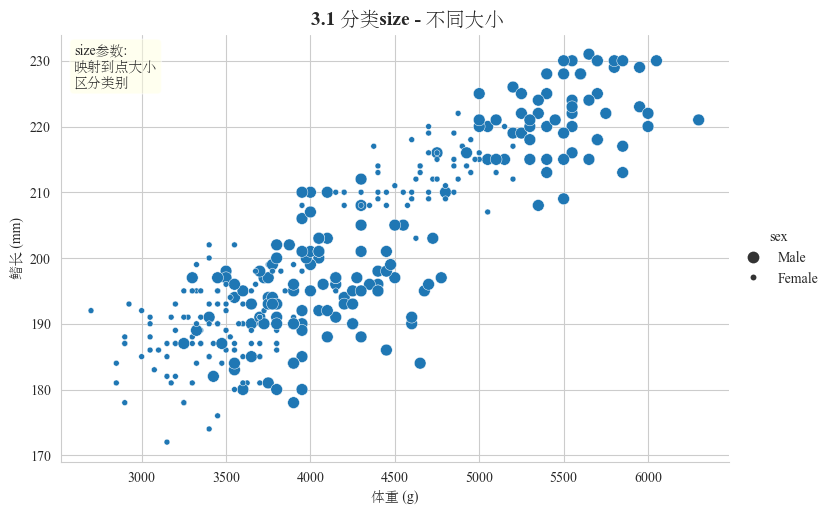

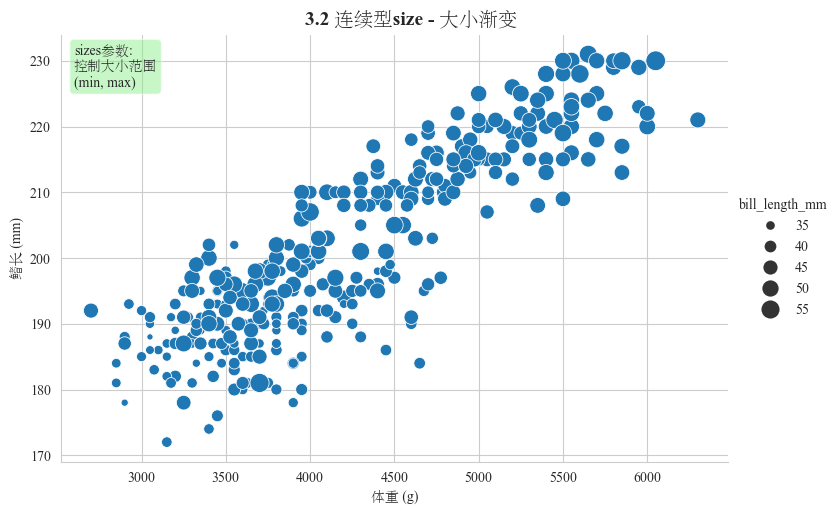

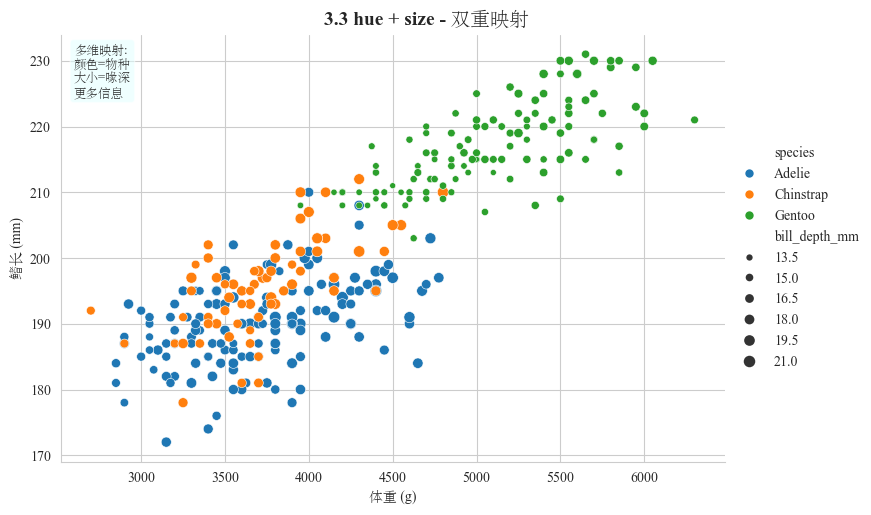

In [15]:
# ============================================================
# 画布 2: hue参数 - 颜色映射
# ============================================================
print("\n画布 2: hue参数 - 颜色映射")  # 打印画布标题:空行+画布2主题
print("-" * 60)  # 打印60个连字符:子画布分隔线

# ========== 2.1 scatter + hue ==========
g = sns.relplot(data=penguins,  # 数据集:企鹅数据(333行)
                x='body_mass_g',  # X轴:体重(克),连续数值
                y='flipper_length_mm',  # Y轴:鳍长(毫米),连续数值
                hue='species',  # 颜色分组:分类变量(3类:Adelie/Chinstrap/Gentoo),自动分配3种颜色
                height=5,  # 分面高度:5英寸(单分面总高=5)
                aspect=1.5)  # 宽高比:1.5(总宽=5*1.5=7.5英寸)
g.fig.suptitle('2.1 Scatter + hue - 颜色分组',  # Figure主标题:说明hue分组
               fontsize=14,  # 标题字体:14pt
               fontweight='bold',  # 标题粗体
               y=1.02)  # 标题位置:上方1.02倍(避免与图形重叠)
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 统一轴标签:所有分面共用
plt.show()  # 显示第1个图形:散点图+3色物种分组

# ========== 2.2 line + hue ==========
g = sns.relplot(data=flights,  # 数据集:航班数据(144行)
                x='year',  # X轴:年份(1949-1960),分类型
                y='passengers',  # Y轴:乘客数,数值型
                hue='month',  # 颜色分组:分类变量(12个月),自动分配12种颜色
                kind='line',  # 图表类型:折线图
                height=5,  # 分面高度:5英寸
                aspect=1.5)  # 宽高比:1.5
g.fig.suptitle('2.2 Line + hue - 多条线对比',  # 主标题:12条月份线对比
               fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('年份', '乘客数')  # 简洁中文轴标签
plt.show()  # 显示第2个图形:12条月份趋势线

# ========== 2.3 hue + palette ==========
g = sns.relplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                hue='species',  # 3类物种
                palette='Set2',  # 自定义调色板:Set2(8色柔和配色方案),取前3色
                height=5,
                aspect=1.5)
g.fig.suptitle('2.3 hue + palette - 自定义配色',  # 主标题:强调调色板
               fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('体重 (g)', '鳍长 (mm)')
plt.show()  # 显示第3个图形:相同分组+Set2柔和配色

# ========== 2.4 连续型hue ==========
g = sns.relplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                hue='bill_length_mm',  # 连续变量:喙长(毫米),映射到颜色渐变
                palette='viridis',  # 连续调色板:viridis(感知均匀:紫-蓝-绿-黄)
                height=5,
                aspect=1.5)
g.fig.suptitle('2.4 连续型hue - 颜色渐变', fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('体重 (g)', '鳍长 (mm)')
plt.show()  # 显示第4个图形:喙长颜色渐变散点

# ============================================================
# 画布 3: size参数 - 大小映射
# ============================================================
print("\n画布 3: size参数 - 大小映射")  # 打印画布3标题:空行+主题
print("-" * 60)  # 60个连字符分隔线

# ========== 3.1 分类size ==========
g = sns.relplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                size='sex',  # 分类变量:性别(2类:Male/Female),分配2种固定点大小
                height=5,
                aspect=1.5)
g.fig.suptitle('3.1 分类size - 不同大小', fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('体重 (g)', '鳍长 (mm)')
g.ax.text(0.02,  # 文本X:左边2%(0-1相对坐标)
          0.98,  # 文本Y:顶部2%
          'size参数:\n映射到点大小\n区分类别',  # 多行说明:size分类作用
          transform=g.ax.transAxes,  # 坐标系:Axes相对坐标
          fontsize=10,  # 字体:10pt
          verticalalignment='top',  # 垂直对齐:顶部
          bbox=dict(boxstyle='round',  # 圆角背景框
                    facecolor='lightyellow',  # 浅黄色背景
                    alpha=0.5))  # 50%透明度
plt.show()  # 显示第5个图形:性别2种点大小

# ========== 3.2 连续型size ==========
g = sns.relplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                size='bill_length_mm',  # 连续变量:喙长(毫米),映射到点大小渐变
                sizes=(20, 200),  # 大小范围:最小20像素,最大200像素
                height=5,
                aspect=1.5)
g.fig.suptitle('3.2 连续型size - 大小渐变', fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('体重 (g)', '鳍长 (mm)')
g.ax.text(0.02,
          0.98,
          'sizes参数:\n控制大小范围\n(min, max)',  # 说明sizes范围控制
          transform=g.ax.transAxes,
          fontsize=10,
          verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景
plt.show()  # 显示第6个图形:喙长大小渐变

# ========== 3.3 hue + size组合 ==========
g = sns.relplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                hue='species',  # 颜色:3类物种
                size='bill_depth_mm',  # 大小:喙深(连续),映射到点大小
                height=5,
                aspect=1.5)
g.fig.suptitle('3.3 hue + size - 双重映射', fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('体重 (g)', '鳍长 (mm)')
g.ax.text(0.02,
          0.98,
          '多维映射:\n颜色=物种\n大小=喙深\n更多信息',  # 双维映射说明
          transform=g.ax.transAxes,
          fontsize=9,  # 9pt(内容稍多,字体稍小)
          verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 浅青色背景
plt.show()  # 显示第7个图形:3色+大小渐变组合


画布 4: style参数 - 样式映射
------------------------------------------------------------


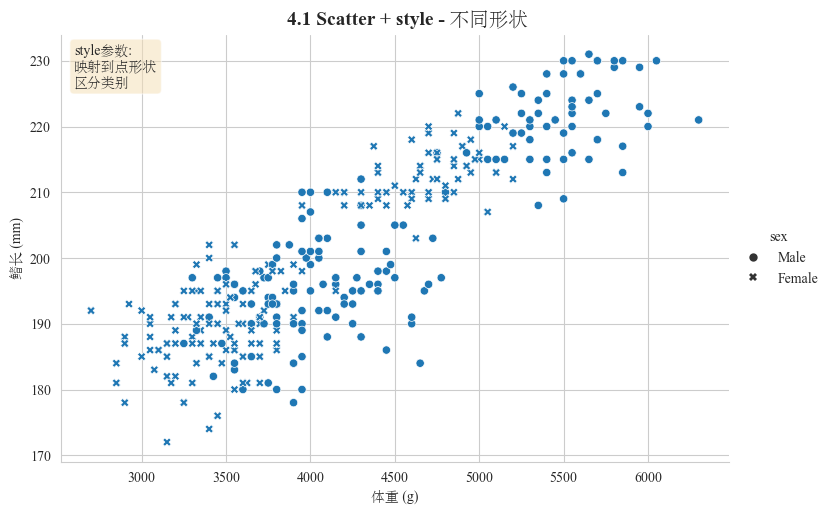

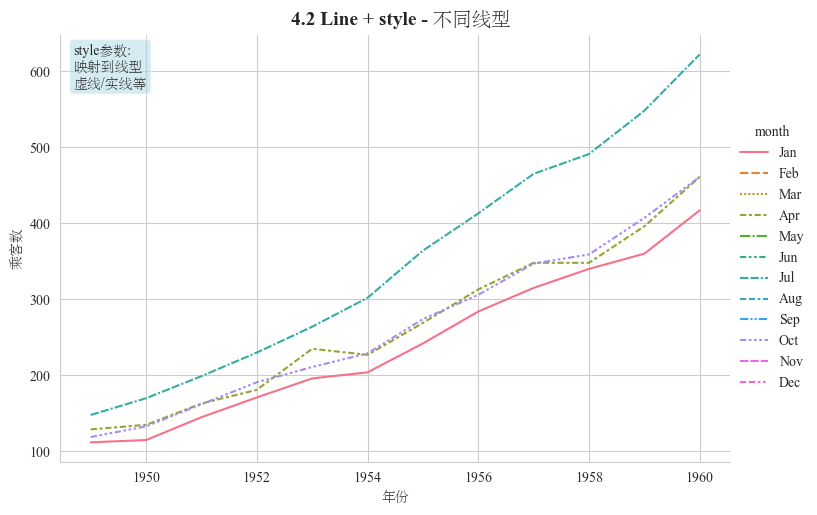

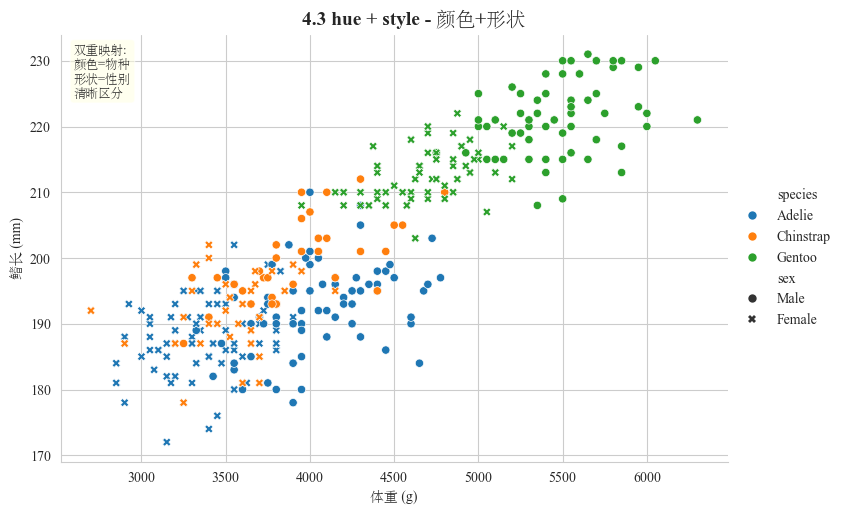

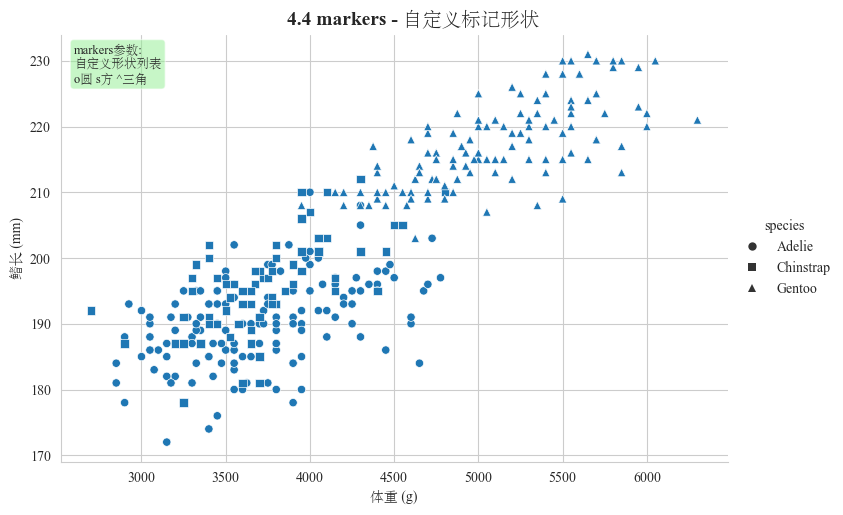

In [16]:
# ============================================================
# 画布 4: style参数 - 样式映射
# ============================================================
print("\n画布 4: style参数 - 样式映射")  # 打印画布4标题:空行+主题
print("-" * 60)  # 打印60个连字符:子画布分隔线

# ========== 4.1 scatter + style ==========
g = sns.relplot(data=penguins,  # 数据集:企鹅数据(333行)
                x='body_mass_g',  # X轴:体重(克)
                y='flipper_length_mm',  # Y轴:鳍长(毫米)
                style='sex',  # 形状分组:分类变量(2类:Male/Female),自动分配2种标记(o=圆圈,s=方块)
                height=5,  # 分面高度:5英寸
                aspect=1.5)  # 宽高比:1.5(总宽7.5英寸)
g.fig.suptitle('4.1 Scatter + style - 不同形状',  # 主标题:说明形状分组
               fontsize=14,  # 标题字体:14pt
               fontweight='bold',  # 标题粗体
               y=1.02)  # 标题位置:上方1.02倍
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 统一轴标签
g.ax.text(0.02,  # 文本X:左边2%
          0.98,  # 文本Y:顶部2%
          'style参数:\n映射到点形状\n区分类别',  # 多行说明:style分类作用
          transform=g.ax.transAxes,  # Axes相对坐标系(0-1)
          fontsize=10,  # 字体:10pt
          verticalalignment='top',  # 垂直对齐:顶部
          bbox=dict(boxstyle='round',  # 圆角背景框
                    facecolor='wheat',  # 小麦色背景
                    alpha=0.5))  # 50%透明度
plt.show()  # 显示第8个图形:性别2种形状散点

# ========== 4.2 line + style ==========
g = sns.relplot(data=flights.query('month in ["Jan", "Apr", "Jul", "Oct"]'),  # 数据筛选:仅4个月(48行),query()字符串过滤
                x='year',  # X轴:年份(1949-1960)
                y='passengers',  # Y轴:乘客数
                hue='month',  # 颜色分组:4个月,4种颜色
                style='month',  # 线型分组:4个月,4种线型(实线/虚线/点线等)
                kind='line',  # 图表类型:折线图
                height=5,
                aspect=1.5)
g.fig.suptitle('4.2 Line + style - 不同线型',  # 主标题:4种线型对比
               fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('年份', '乘客数')  # 简洁中文标签
g.ax.text(0.02,
          0.98,
          'style参数:\n映射到线型\n虚线/实线等',  # 说明线型映射
          transform=g.ax.transAxes,
          fontsize=10,
          verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景
plt.show()  # 显示第9个图形:4个月4色4线型

# ========== 4.3 hue + style组合 ==========
g = sns.relplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                hue='species',  # 颜色分组:3类物种,3种颜色
                style='sex',  # 形状分组:2类性别,2种标记
                height=5,
                aspect=1.5)
# 组合效果:3物种×2性别=6种组合(6种颜色+形状组合)
g.fig.suptitle('4.3 hue + style - 颜色+形状', fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('体重 (g)', '鳍长 (mm)')
g.ax.text(0.02,
          0.98,
          '双重映射:\n颜色=物种\n形状=性别\n清晰区分',  # 双维映射说明
          transform=g.ax.transAxes,
          fontsize=9,  # 9pt(内容多,字体稍小)
          verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))  # 浅黄色背景
plt.show()  # 显示第10个图形:6种颜色+形状组合

# ========== 4.4 markers自定义标记 ==========
g = sns.relplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                style='species',  # 形状分组:3类物种
                markers=['o', 's', '^'],  # 自定义标记列表:对应3物种顺序
                # o=圆圈(Adelie), s=方块(Chinstrap), ^=上三角(Gentoo)
                height=5,
                aspect=1.5)
g.fig.suptitle('4.4 markers - 自定义标记形状', fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('体重 (g)', '鳍长 (mm)')
g.ax.text(0.02,
          0.98,
          'markers参数:\n自定义形状列表\no圆 s方 ^三角',  # 具体标记含义说明
          transform=g.ax.transAxes,
          fontsize=9,
          verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景
plt.show()  # 显示第11个图形:3种自定义标记


画布 5: col/row参数 - 分面
------------------------------------------------------------


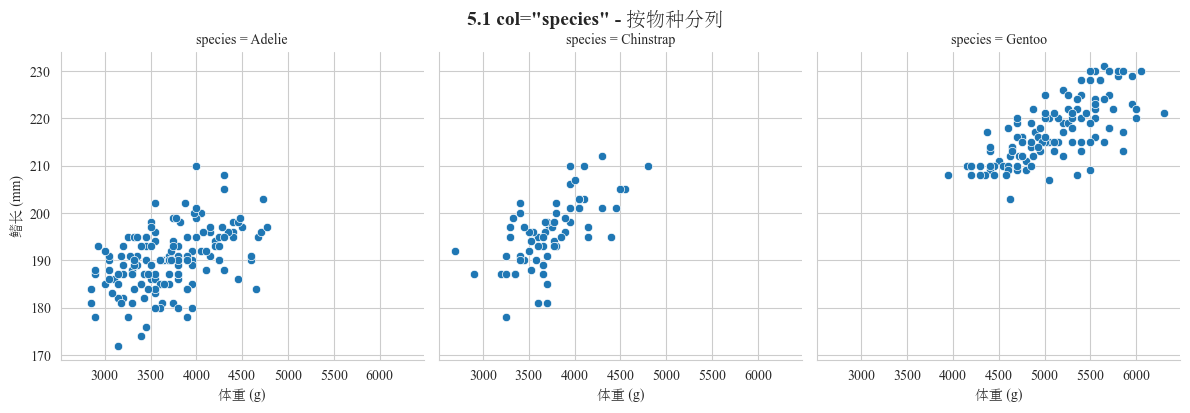

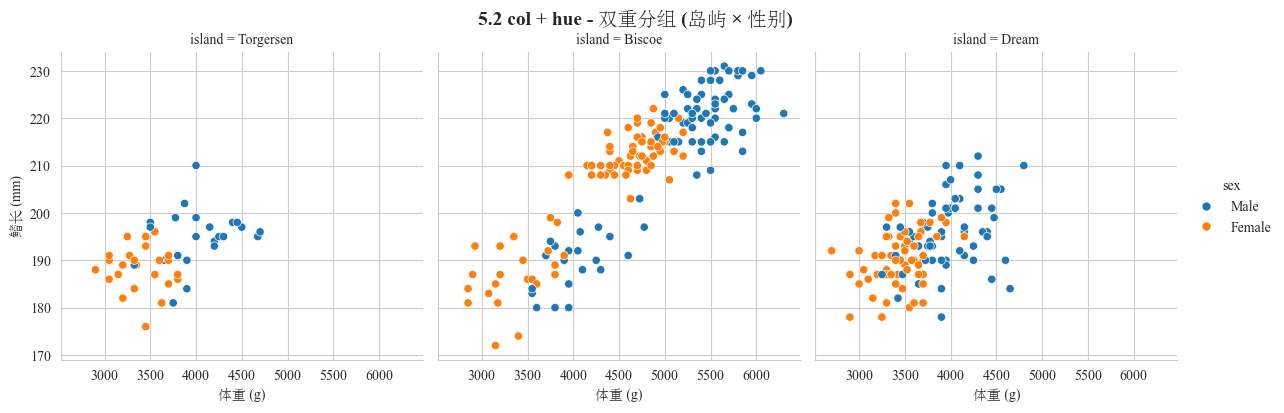

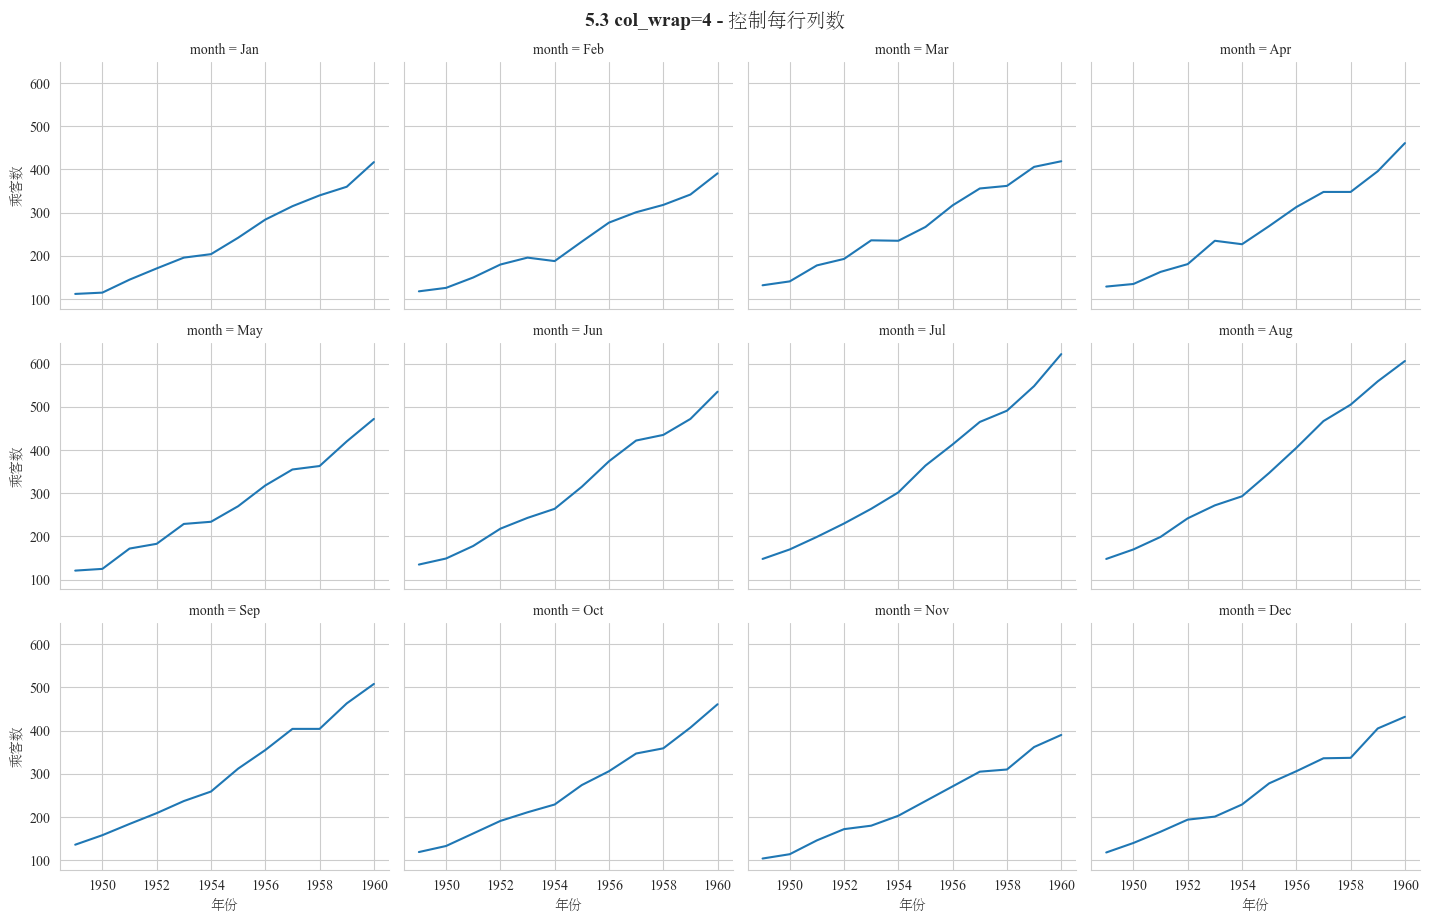

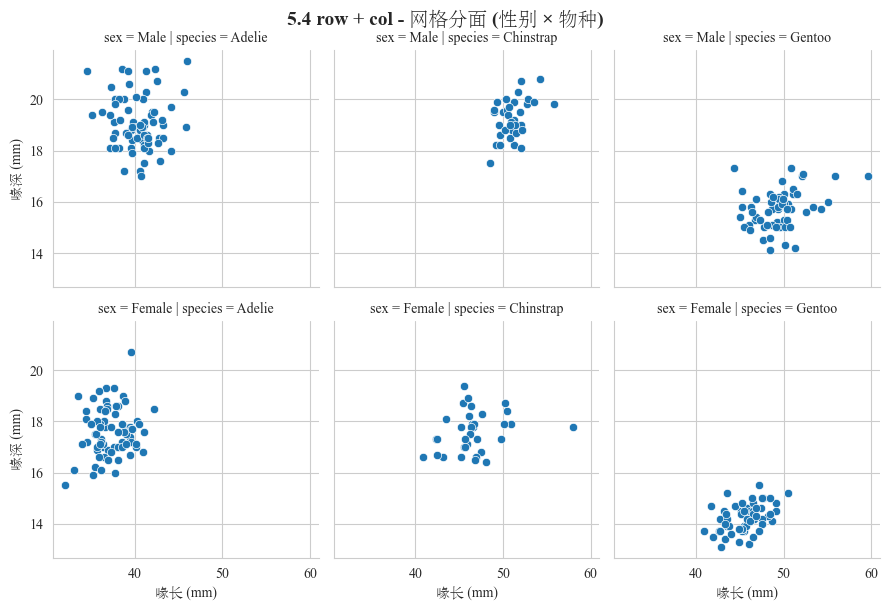

In [17]:
# ============================================================
# 画布 5: col/row参数 - 分面
# ============================================================
print("\n画布 5: col/row参数 - 分面")  # 打印画布5标题:空行+分面主题
print("-" * 60)  # 打印60个连字符:子画布分隔线

# ========== 5.1 基础列分面 ==========
g = sns.relplot(data=penguins,  # 数据集:企鹅数据(333行)
                x='body_mass_g',  # X轴:体重(克)
                y='flipper_length_mm',  # Y轴:鳍长(毫米)
                col='species',  # 列分面:分类变量(3类:Adelie/Chinstrap/Gentoo)→3列分面
                height=4,  # 分面高度:4英寸(比前例5小,3列布局更紧凑)
                aspect=1)  # 宽高比:1(正方形,适合多列)
g.fig.suptitle('5.1 col="species" - 按物种分列',  # 主标题:3列物种分面
               fontsize=14,  # 标题字体:14pt
               fontweight='bold',  # 标题粗体
               y=1.02)  # 标题位置:上方1.02倍
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 统一所有分面轴标签
plt.show()  # 显示第12个图形:1行3列散点图(3种物种)

# ========== 5.2 col + hue双重分组 ==========
g = sns.relplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                col='island',  # 列分面:岛屿(3类:Biscoe/Dream/Torgersen)→3列
                hue='sex',  # 颜色分组:性别(2类:Male/Female)→每列2色
                height=4,  # 分面高度:4英寸
                aspect=1)  # 正方形
# 组合效果:3岛屿×2性别=6组数据,3列×2色
g.fig.suptitle('5.2 col + hue - 双重分组 (岛屿 × 性别)',  # 主标题:说明双重分组
               fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('体重 (g)', '鳍长 (mm)')
plt.show()  # 显示第13个图形:3列×2色散点图

# ========== 5.3 col_wrap控制换行 ==========
g = sns.relplot(data=flights,  # 数据集:航班数据(144行)
                x='year',  # X轴:年份
                y='passengers',  # Y轴:乘客数
                col='month',  # 列分面:12个月→12个分面
                col_wrap=4,  # 每行4列:12÷4=3行(4-4-4布局)
                kind='line',  # 图表类型:折线图
                height=3,  # 分面高度:3英寸(多分面更小)
                aspect=1.2)  # 宽高比:1.2(稍宽,适合时间序列)
# 总布局:3行4列=12个月份趋势线
g.fig.suptitle('5.3 col_wrap=4 - 控制每行列数',  # 主标题:说明换行控制
               fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('年份', '乘客数')
plt.show()  # 显示第14个图形:3×4网格12条月份线

# ========== 5.4 row + col网格分面 ==========
g = sns.relplot(data=penguins,
                x='bill_length_mm',  # X轴:喙长(毫米)
                y='bill_depth_mm',  # Y轴:喙深(毫米)
                row='sex',  # 行分面:性别(2类)→2行
                col='species',  # 列分面:物种(3类)→3列
                height=3,  # 分面高度:3英寸(2×3=6个小图)
                aspect=1)  # 正方形
# 网格效果:2行×3列=6个分面(2性别×3物种)
g.fig.suptitle('5.4 row + col - 网格分面 (性别 × 物种)',  # 主标题:2×3网格
               fontsize=14, fontweight='bold', y=1.01)  # y=1.01(多行分面标题稍低)
g.set_axis_labels('喙长 (mm)', '喙深 (mm)')
plt.show()  # 显示第15个图形:2×3网格喙长vs喙深散点


画布 6: 多重映射组合
------------------------------------------------------------


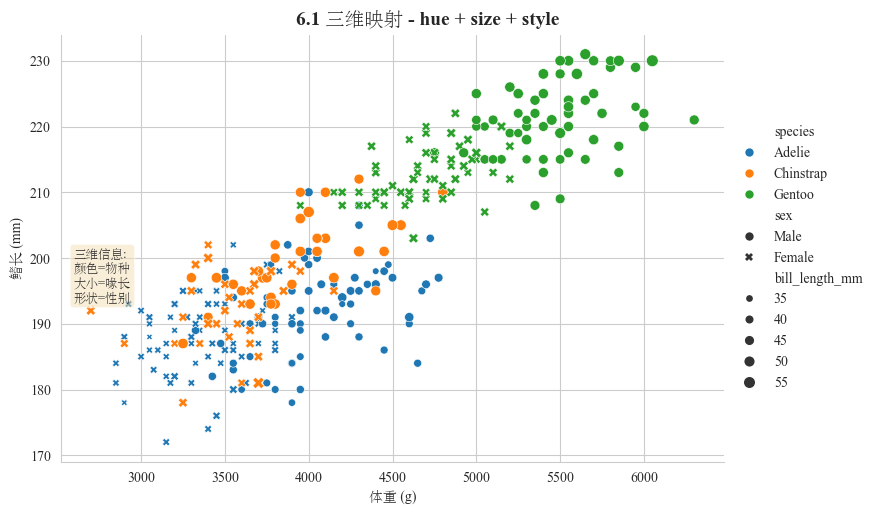

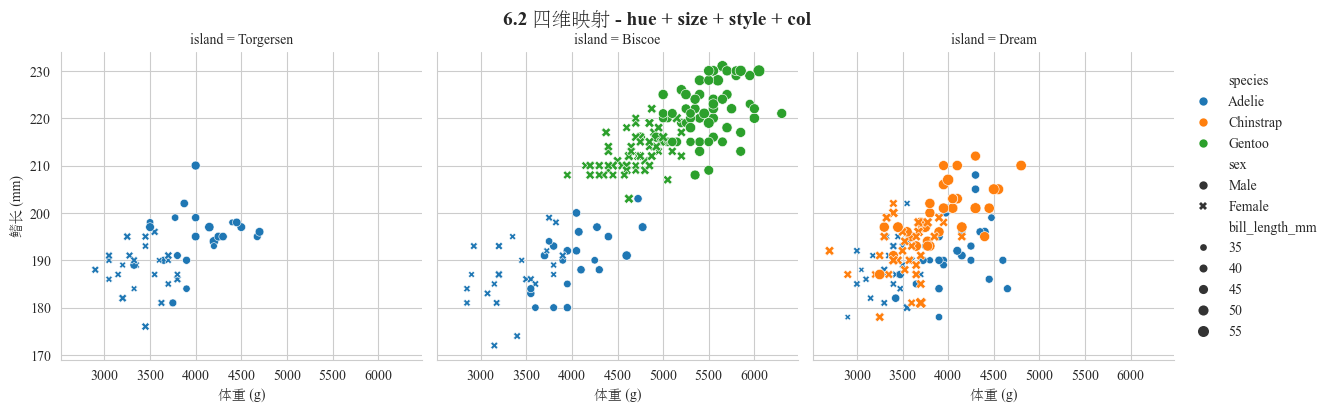

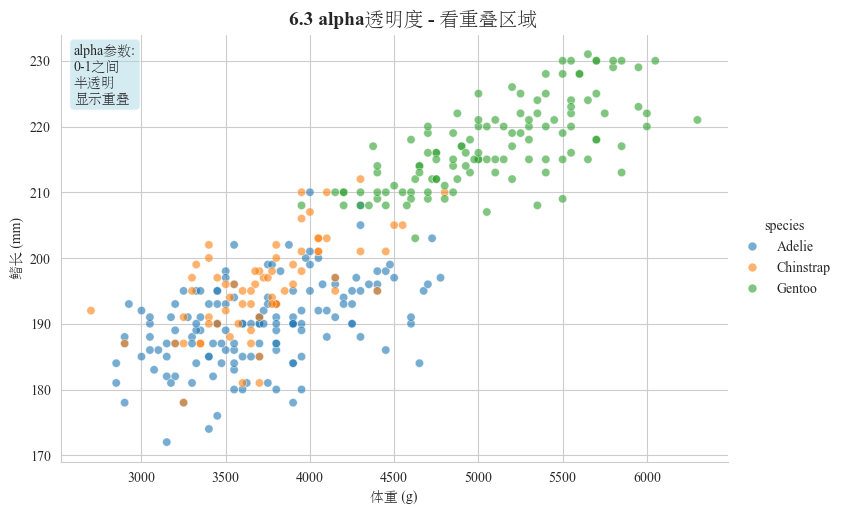

In [18]:
# ============================================================
# 画布 6: 多重映射组合
# ============================================================
print("\n画布 6: 多重映射组合")  # 打印画布6标题:空行+多重映射主题
print("-" * 60)  # 打印60个连字符:子画布分隔线

# ========== 6.1 三维映射 ==========
g = sns.relplot(data=penguins,  # 数据集:企鹅数据(333行)
                x='body_mass_g',  # X轴:体重(克),第1维
                y='flipper_length_mm',  # Y轴:鳍长(毫米),第2维
                hue='species',  # 颜色分组:3类物种→3种颜色,第3维
                size='bill_length_mm',  # 大小分组:喙长(连续)→大小渐变,第4维
                style='sex',  # 形状分组:2类性别→2种标记,第5维
                height=5,  # 分面高度:5英寸(单分面)
                aspect=1.5)  # 宽高比:1.5(横向)
# 组合效果:3物种×2性别=6组,每组大小渐变→**5维可视化**(X,Y+3美学)
g.fig.suptitle('6.1 三维映射 - hue + size + style',  # 主标题:3种美学映射
               fontsize=14,  # 标题字体:14pt
               fontweight='bold',  # 标题粗体
               y=1.02)  # 标题位置:上方1.02倍
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 统一轴标签
g.ax.text(0.02,  # 文本X:左边2%
          0.50,  # 文本Y:中部50%(位置下移避免图例重叠)
          '三维信息:\n颜色=物种\n大小=喙长\n形状=性别',  # 三维映射对应说明
          transform=g.ax.transAxes,  # Axes相对坐标系
          fontsize=9,  # 字体:9pt(内容多)
          verticalalignment='top',  # 垂直对齐:顶部
          bbox=dict(boxstyle='round',  # 圆角背景框
                    facecolor='wheat',  # 小麦色背景
                    alpha=0.5))  # 50%透明度
plt.show()  # 显示第16个图形:5维散点图(3色×2形×大小渐变)

# ========== 6.2 四维映射 ==========
g = sns.relplot(data=penguins,
                x='body_mass_g',  # X轴:第1维
                y='flipper_length_mm',  # Y轴:第2维
                hue='species',  # 颜色:3类→第3维
                size='bill_length_mm',  # 大小:连续→第4维
                style='sex',  # 形状:2类→第5维
                col='island',  # 列分面:3岛屿→3列,第6维
                height=4,  # 分面高度:4英寸(3列紧凑)
                aspect=1)  # 正方形
# **终极6维可视化**:3岛屿列×(3物种色×2性别形×喙长大小)
g.fig.suptitle('6.2 四维映射 - hue + size + style + col',  # 主标题:4种映射
               fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('体重 (g)', '鳍长 (mm)')
plt.show()  # 显示第17个图形:3列×5维散点图(18组数据)

# ========== 6.3 透明度alpha ==========
g = sns.relplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                hue='species',  # 仅颜色分组(3色)
                alpha=0.6,  # 全局透明度:60%不透明(40%透明),解决重叠显示
                height=5,
                aspect=1.5)
g.fig.suptitle('6.3 alpha透明度 - 看重叠区域', fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('体重 (g)', '鳍长 (mm)')
g.ax.text(0.02,  # 左2%
          0.98,  # 顶部2%(无多维图例,位置上移)
          'alpha参数:\n0-1之间\n半透明\n显示重叠',  # alpha功能说明
          transform=g.ax.transAxes,
          fontsize=10,  # 10pt(内容少)
          verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景
plt.show()  # 显示第18个图形:3色半透明散点(重叠区域可见)


画布 7: line特有参数
------------------------------------------------------------


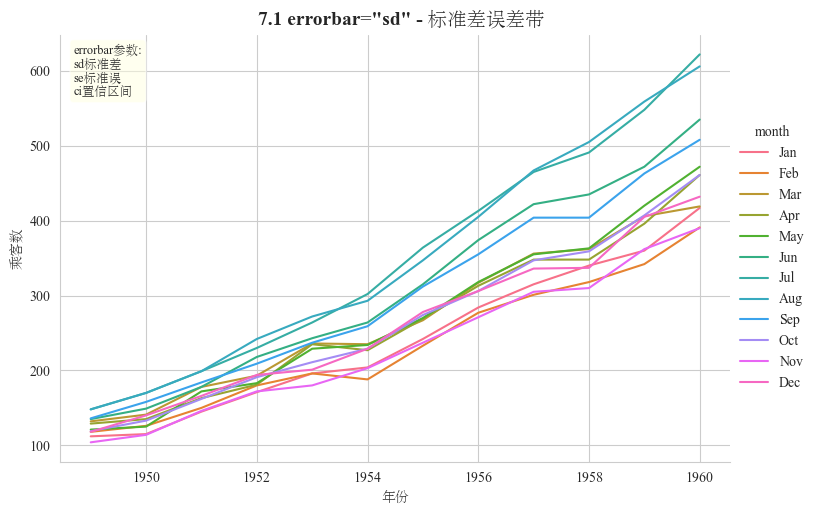

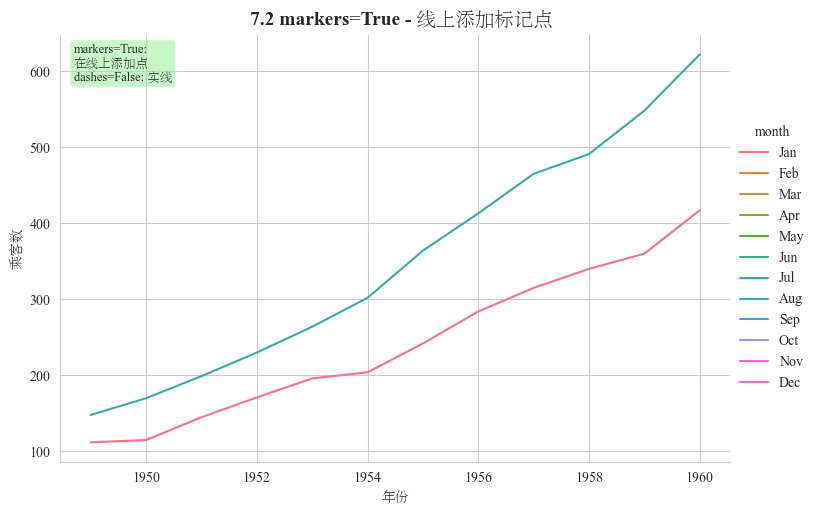

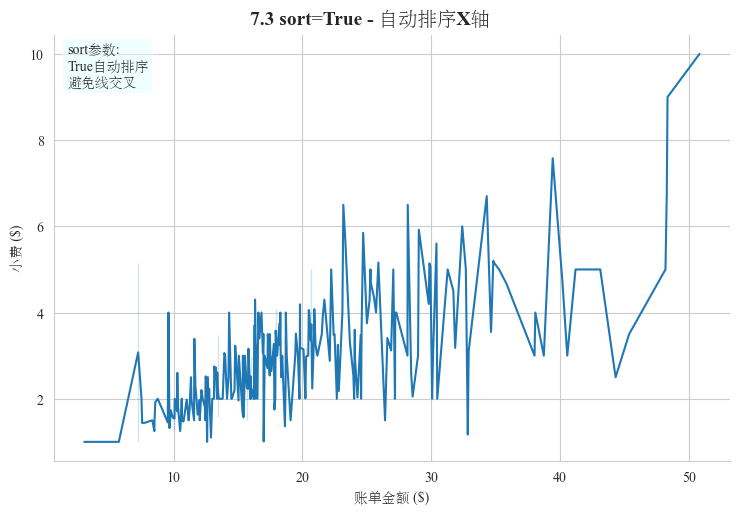

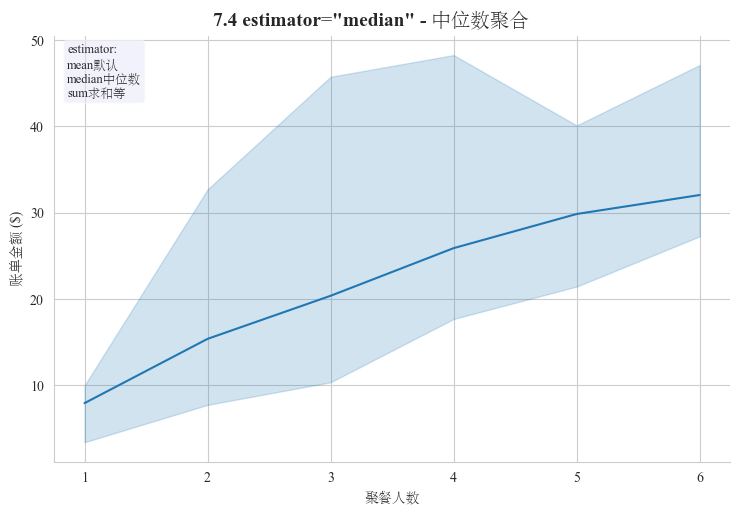

In [19]:
# ============================================================
# 画布 7: line特有参数
# ============================================================
print("\n画布 7: line特有参数")  # 打印画布7标题:空行+line特有参数主题
print("-" * 60)  # 打印60个连字符:子画布分隔线

# ========== 7.1 errorbar误差带 ==========
g = sns.relplot(data=flights,  # 数据集:航班数据(144行)
                x='year',  # X轴:年份(1949-1960)
                y='passengers',  # Y轴:乘客数
                hue='month',  # 颜色分组:12个月→12条线+误差带
                kind='line',  # 图表类型:折线图
                errorbar='sd',  # 误差带类型:sd=标准差(显示月度变异性)
                height=5,  # 分面高度:5英寸
                aspect=1.5)  # 宽高比:1.5(横向)
g.fig.suptitle('7.1 errorbar="sd" - 标准差误差带',  # 主标题:标准差带
               fontsize=14,  # 标题字体:14pt
               fontweight='bold',  # 标题粗体
               y=1.02)  # 标题位置:上方1.02倍
g.set_axis_labels('年份', '乘客数')  # 统一轴标签
g.ax.text(0.02,  # 文本X:左边2%
          0.98,  # 文本Y:顶部2%
          'errorbar参数:\nsd标准差\nse标准误\nci置信区间',  # 3种误差带选项说明
          transform=g.ax.transAxes,  # Axes相对坐标系
          fontsize=9,  # 字体:9pt
          verticalalignment='top',  # 垂直对齐:顶部
          bbox=dict(boxstyle='round',  # 圆角背景框
                    facecolor='lightyellow',  # 浅黄色背景
                    alpha=0.5))  # 50%透明度
plt.show()  # 显示第19个图形:12条线+标准差带

# ========== 7.2 markers添加标记点 ==========
g = sns.relplot(data=flights.query('month in ["Jan", "Jul"]'),  # 筛选数据:仅1月+7月(24行)
                x='year',  # X轴:年份
                y='passengers',  # Y轴:乘客数
                hue='month',  # 颜色分组:2个月→2条线
                kind='line',
                markers=True,  # 添加标记点:每个年份显示圆点
                dashes=False,  # 禁用虚线:强制所有线为实线
                height=5,
                aspect=1.5)
g.fig.suptitle('7.2 markers=True - 线上添加标记点',  # 主标题:标记点+实线
               fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('年份', '乘客数')
g.ax.text(0.02,
          0.98,
          'markers=True:\n在线上添加点\ndashes=False: 实线',  # 标记+实线说明
          transform=g.ax.transAxes,
          fontsize=9,
          verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))  # 浅绿色背景
plt.show()  # 显示第20个图形:2条实线+12个标记点

# ========== 7.3 sort排序 ==========
# 创建无序数据:打乱tips数据集顺序
unsorted_data = tips.sample(frac=1, random_state=42)  # 100%随机采样,种子42确保可重现
g = sns.relplot(data=unsorted_data,  # 无序数据(244行)
                x='total_bill',  # X轴:账单金额(乱序)
                y='tip',  # Y轴:小费
                kind='line',  # 折线图(单线连接所有点)
                sort=True,  # 自动排序:按x轴(total_bill)升序重排后连接
                height=5,
                aspect=1.5)
g.fig.suptitle('7.3 sort=True - 自动排序X轴',  # 主标题:排序避免交叉
               fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('账单金额 ($)', '小费 ($)')  # 美金符号
g.ax.text(0.02,
          0.98,
          'sort参数:\nTrue自动排序\n避免线交叉',  # 排序作用说明
          transform=g.ax.transAxes,
          fontsize=10,  # 10pt(内容少)
          verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))  # 浅青色背景
plt.show()  # 显示第21个图形:排序后单折线(无交叉)

# ========== 7.4 estimator聚合函数 ==========
g = sns.relplot(data=tips,  # 数据集:小费数据(244行)
                x='size',  # X轴:聚餐人数(分类型:1-6人)
                y='total_bill',  # Y轴:账单金额
                kind='line',
                estimator='median',  # 聚合函数:中位数(替代默认均值mean)
                errorbar=('pi', 95),  # 误差带:95%百分位区间(pi=percentile interval)
                height=5,
                aspect=1.5)
# 效果:每种人数(1-6)计算中位数账单+95%区间
g.fig.suptitle('7.4 estimator="median" - 中位数聚合',  # 主标题:中位数+95%区间
               fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('聚餐人数', '账单金额 ($)')
g.ax.text(0.02,
          0.98,
          'estimator:\nmean默认\nmedian中位数\nsum求和等',  # 聚合函数选项
          transform=g.ax.transAxes,
          fontsize=9,
          verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))  # 淡紫色背景
plt.show()  # 显示第22个图形:6点中位数线+95%误差带


画布 8: scatter特有参数
------------------------------------------------------------


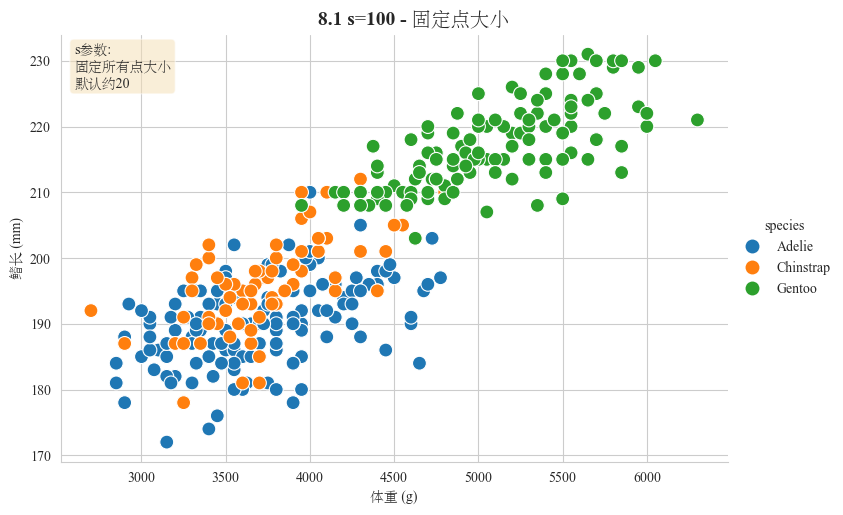

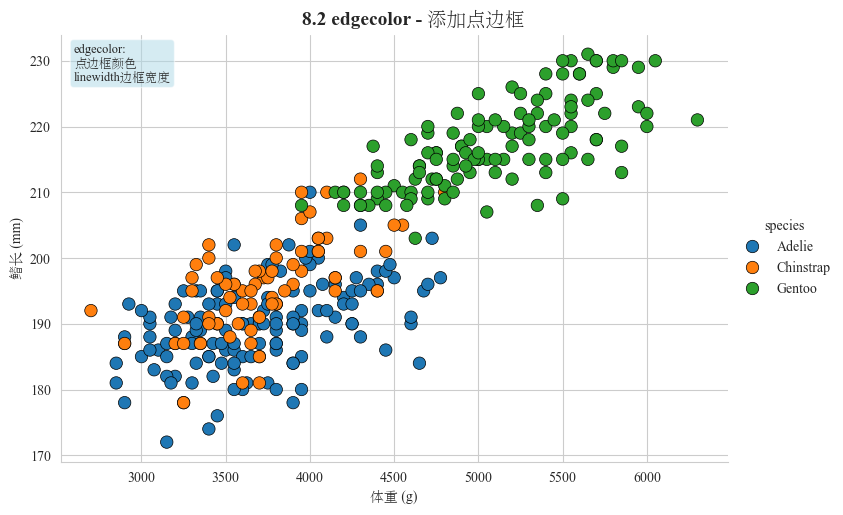


画布 9: 时间序列应用
------------------------------------------------------------


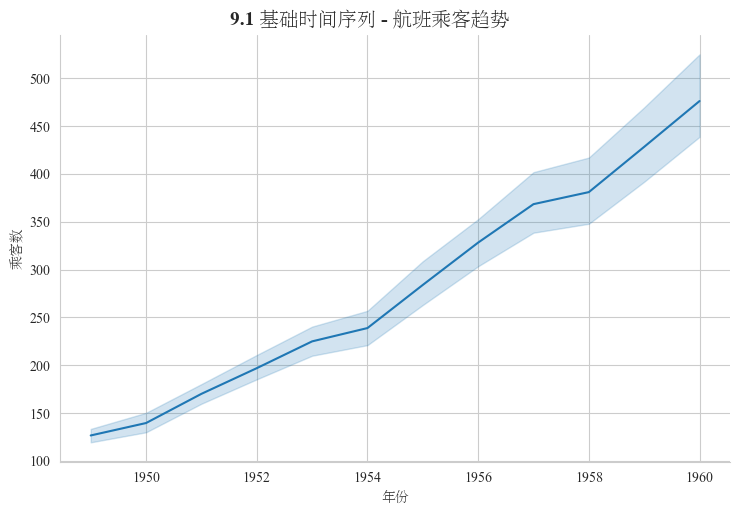

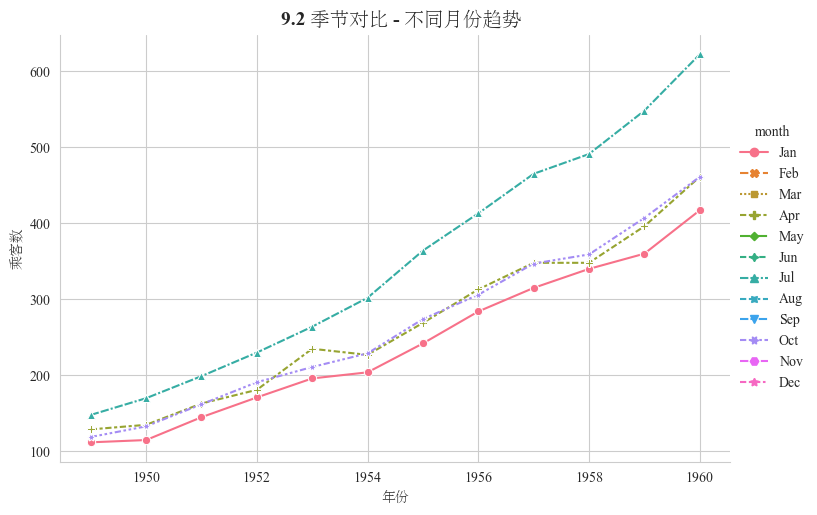

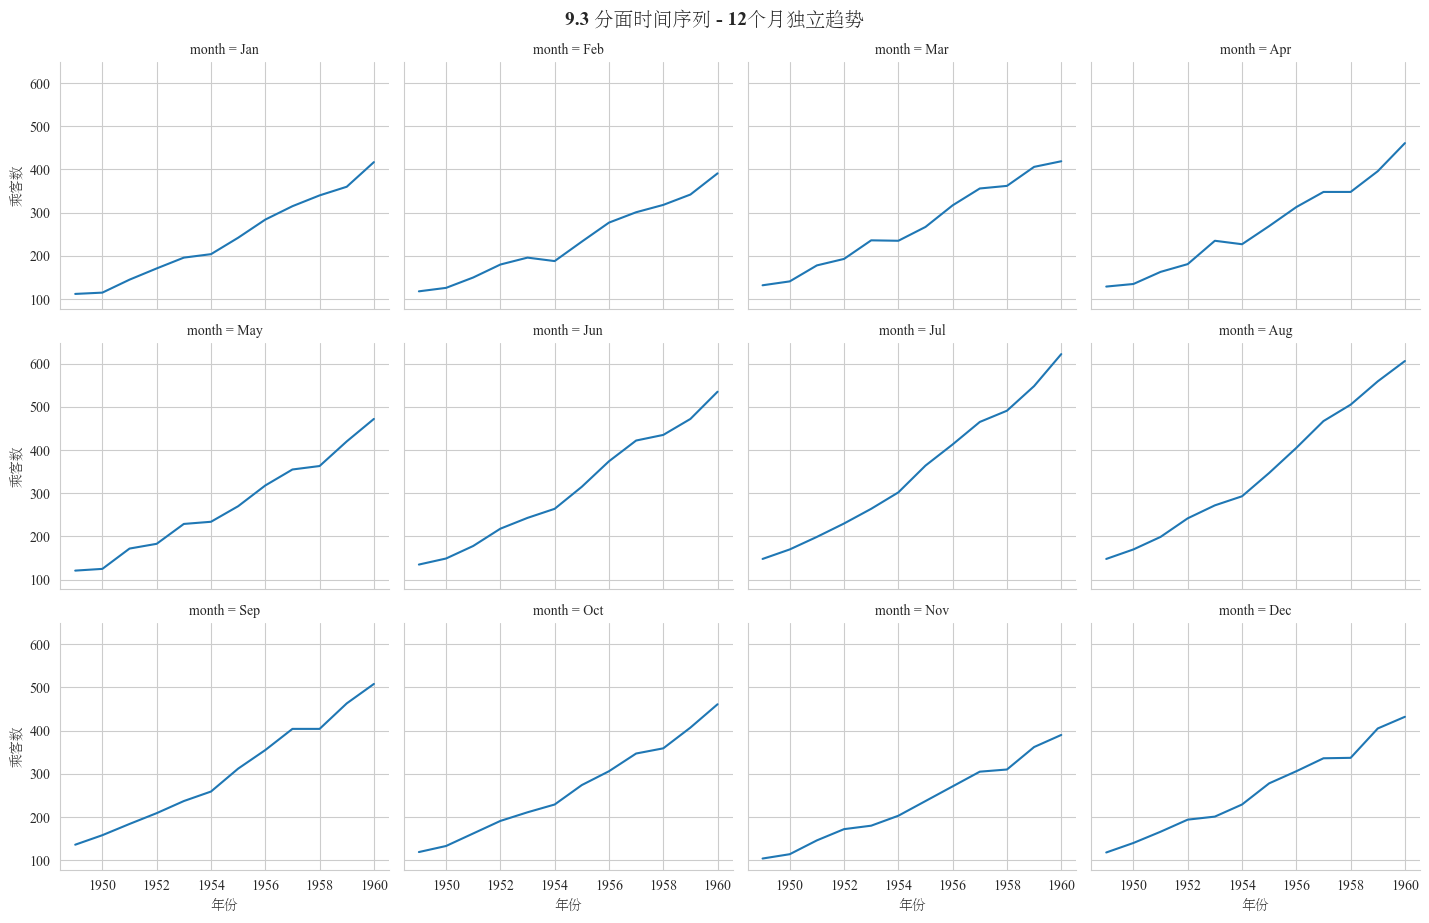

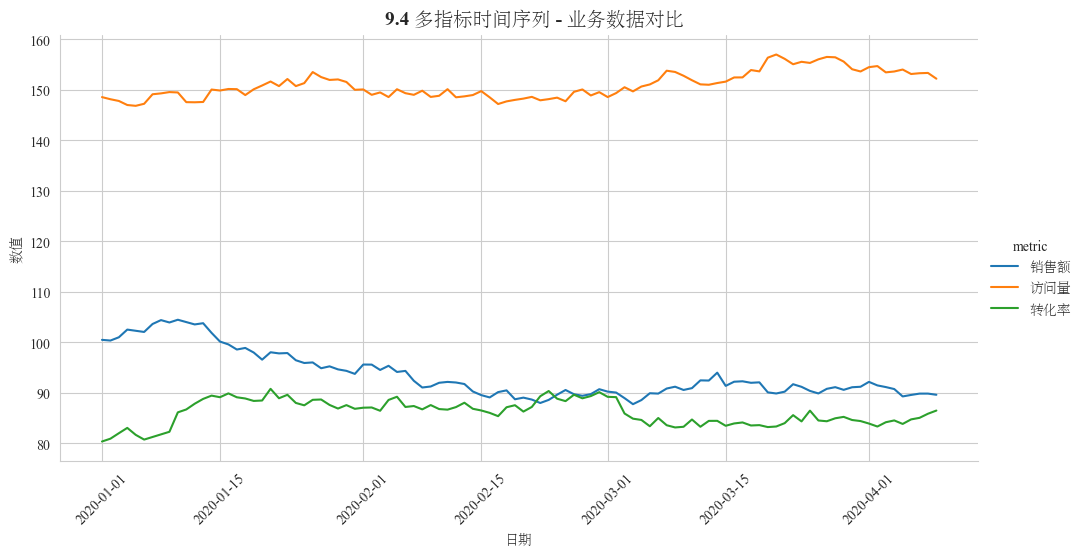

In [ ]:
# ============================================================
# 画布 8: scatter特有参数
# ============================================================
print("\n画布 8: scatter特有参数")  # 打印画布8标题:空行+scatter特有参数主题
print("-" * 60)  # 打印60个连字符:子画布分隔线

# ========== 8.1 s固定大小 ==========
g = sns.relplot(data=penguins,  # 数据集:企鹅数据(333行)
                x='body_mass_g',  # X轴:体重(克)
                y='flipper_length_mm',  # Y轴:鳍长(毫米)
                hue='species',  # 颜色分组:3类物种
                s=100,  # 固定点大小:100像素(默认约20,5倍放大)
                height=5,  # 分面高度:5英寸
                aspect=1.5)  # 宽高比:1.5
g.fig.suptitle('8.1 s=100 - 固定点大小', fontsize=14, fontweight='bold', y=1.02)  # 主标题:固定大小
g.set_axis_labels('体重 (g)', '鳍长 (mm)')  # 统一轴标签
g.ax.text(0.02,  # 文本X:左边2%
          0.98,  # 文本Y:顶部2%
          's参数:\n固定所有点大小\n默认约20',  # s固定大小说明
          transform=g.ax.transAxes,  # Axes相对坐标系
          fontsize=10,  # 字体:10pt
          verticalalignment='top',  # 垂直对齐:顶部
          bbox=dict(boxstyle='round',  # 圆角背景框
                    facecolor='wheat',  # 小麦色背景
                    alpha=0.5))  # 50%透明度
plt.show()  # 显示第23个图形:3色大点散点图

# ========== 8.2 edgecolor边框 ==========
g = sns.relplot(data=penguins,
                x='body_mass_g',
                y='flipper_length_mm',
                hue='species',  # 3色填充
                s=80,  # 点大小:80像素(稍小于100)
                edgecolor='black',  # 边框颜色:黑色轮廓
                linewidth=0.5,  # 边框宽度:0.5pt(细边框)
                height=5,
                aspect=1.5)
g.fig.suptitle('8.2 edgecolor - 添加点边框', fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('体重 (g)', '鳍长 (mm)')
g.ax.text(0.02,
          0.98,
          'edgecolor:\n点边框颜色\nlinewidth边框宽度',  # 边框参数说明
          transform=g.ax.transAxes,
          fontsize=9,  # 9pt(内容多)
          verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))  # 浅蓝色背景
plt.show()  # 显示第24个图形:3色+黑边框散点


# ============================================================
# 画布 9: 时间序列应用
# ============================================================
print("\n画布 9: 时间序列应用")  # 打印画布9标题:空行+时间序列主题
print("-" * 60)  # 60个连字符分隔线

# ========== 9.1 基础时间序列 ==========
g = sns.relplot(data=flights,  # 数据集:航班数据(144行)
                x='year',  # X轴:年份(1949-1960)
                y='passengers',  # Y轴:乘客数(自动按年聚合月度数据)
                kind='line',  # 图表类型:折线图
                height=5,
                aspect=1.5)
g.fig.suptitle('9.1 基础时间序列 - 航班乘客趋势', fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('年份', '乘客数')
plt.show()  # 显示第26个图形:12年乘客趋势单线

# ========== 9.2 多季节对比 ==========
g = sns.relplot(data=flights.query('month in ["Jan", "Apr", "Jul", "Oct"]'),  # 筛选4个月(48行)
                x='year',
                y='passengers',
                hue='month',  # 颜色分组:4个月→4色
                style='month',  # 线型分组:4种线型
                kind='line',
                markers=True,  # 添加标记点
                height=5,
                aspect=1.5)
# 效果:4条不同颜色/线型的季节趋势线+标记点
g.fig.suptitle('9.2 季节对比 - 不同月份趋势', fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('年份', '乘客数')
plt.show()  # 显示第27个图形:4季节对比线图

# ========== 9.3 分面时间序列 ==========
g = sns.relplot(data=flights,
                x='year',
                y='passengers',
                col='month',  # 列分面:12个月→12个分面
                col_wrap=4,  # 每行4列:3行×4列=12分面
                kind='line',
                height=3,  # 小分面高度:3英寸
                aspect=1.2)  # 稍宽比:适合时间序列
# 效果:12个独立月份趋势线(3×4网格)
g.fig.suptitle('9.3 分面时间序列 - 12个月独立趋势', fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('年份', '乘客数')
plt.show()  # 显示第28个图形:12个月分面趋势

# ========== 9.4 多指标对比 ==========
# 创建多指标数据:3个业务指标×100天
np.random.seed(42)  # 随机种子:42确保可重现
dates = pd.date_range('2020-01-01', periods=100, freq='D')  # 日期范围:2020-1-1到4-9,100天,日频
metrics_data = pd.DataFrame({  # 创建300行DataFrame
    'date': np.tile(dates, 3),  # 日期:100天重复3次
    'value': np.concatenate([  # 数值:3条随机游走累计和
        np.cumsum(np.random.randn(100)) + 100,  # 销售额:基线100
        np.cumsum(np.random.randn(100)) + 150,  # 访问量:基线150
        np.cumsum(np.random.randn(100)) + 80   # 转化率:基线80
    ]),
    'metric': np.repeat(['销售额', '访问量', '转化率'], 100)  # 指标:每100行一种
})
g = sns.relplot(data=metrics_data,  # 300行业务数据
                x='date',  # X轴:日期(识别为时间类型,自动格式化)
                y='value',
                hue='metric',  # 颜色分组:3种指标→3色
                kind='line',
                height=5,
                aspect=2)  # 宽高比:2(长条形,适合长序列)
g.fig.suptitle('9.4 多指标时间序列 - 业务数据对比', fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('日期', '数值') #第一个为x轴标签，第二个为y轴标签
plt.setp(g.ax.xaxis.get_majorticklabels(), rotation=45)  # X轴标签:45度旋转(日期不重叠)
plt.show()  # 显示第29个图形:3指标100天趋势对比


画布 10: 综合应用案例
------------------------------------------------------------


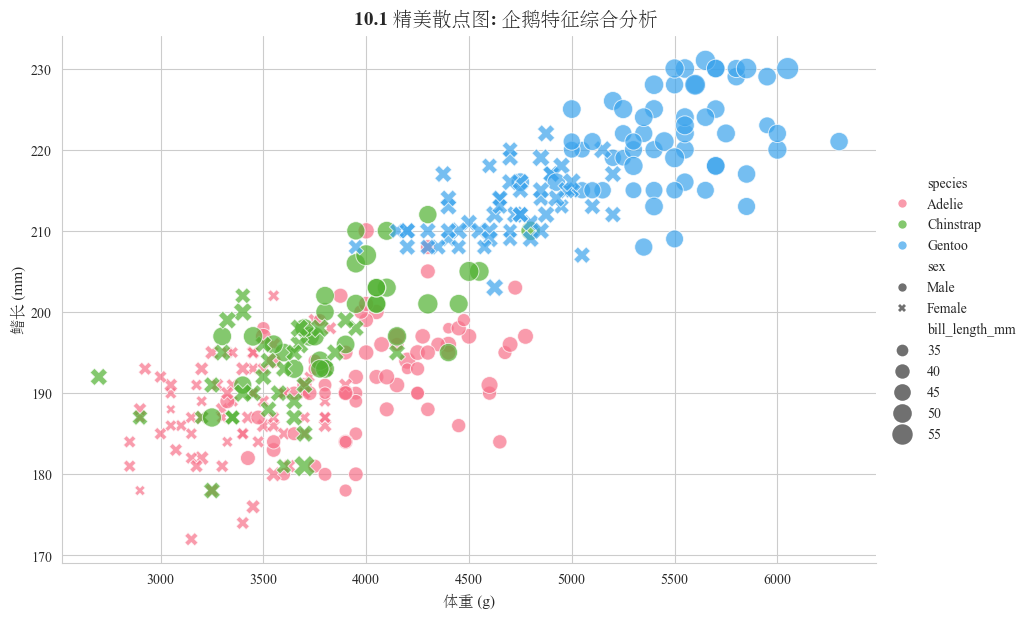

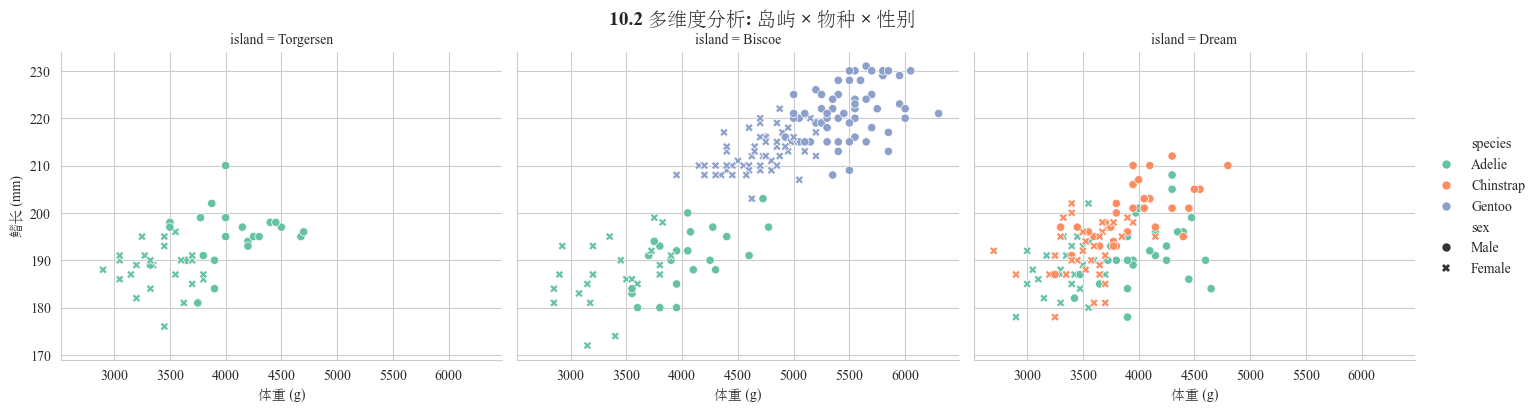

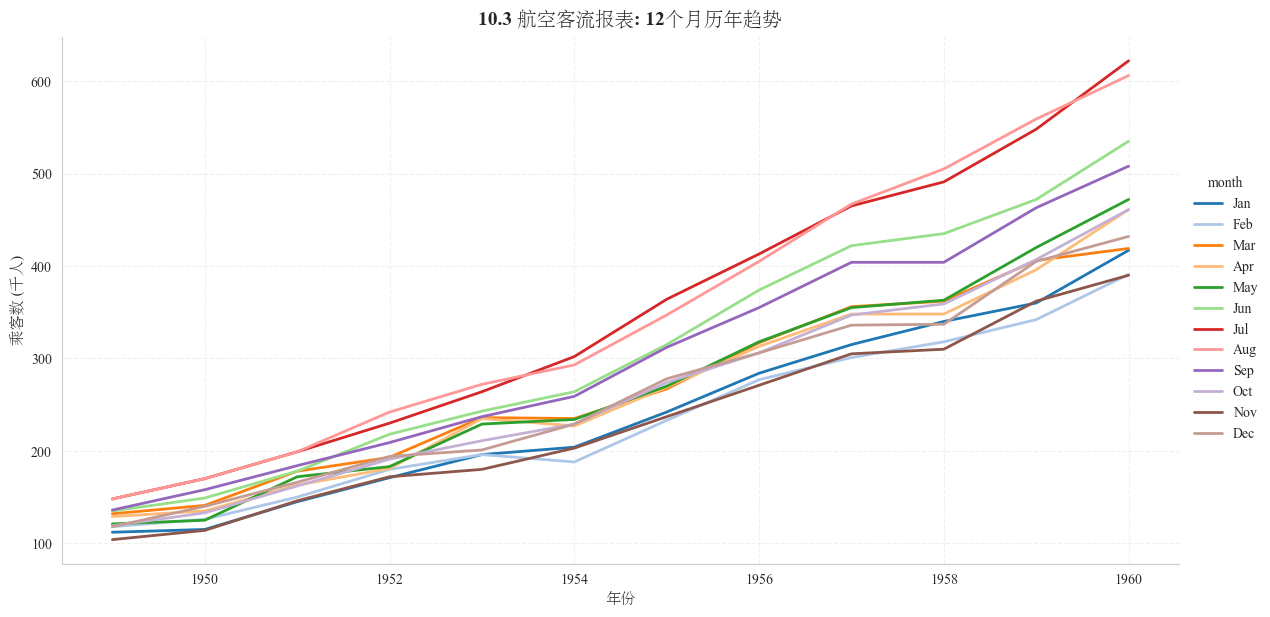

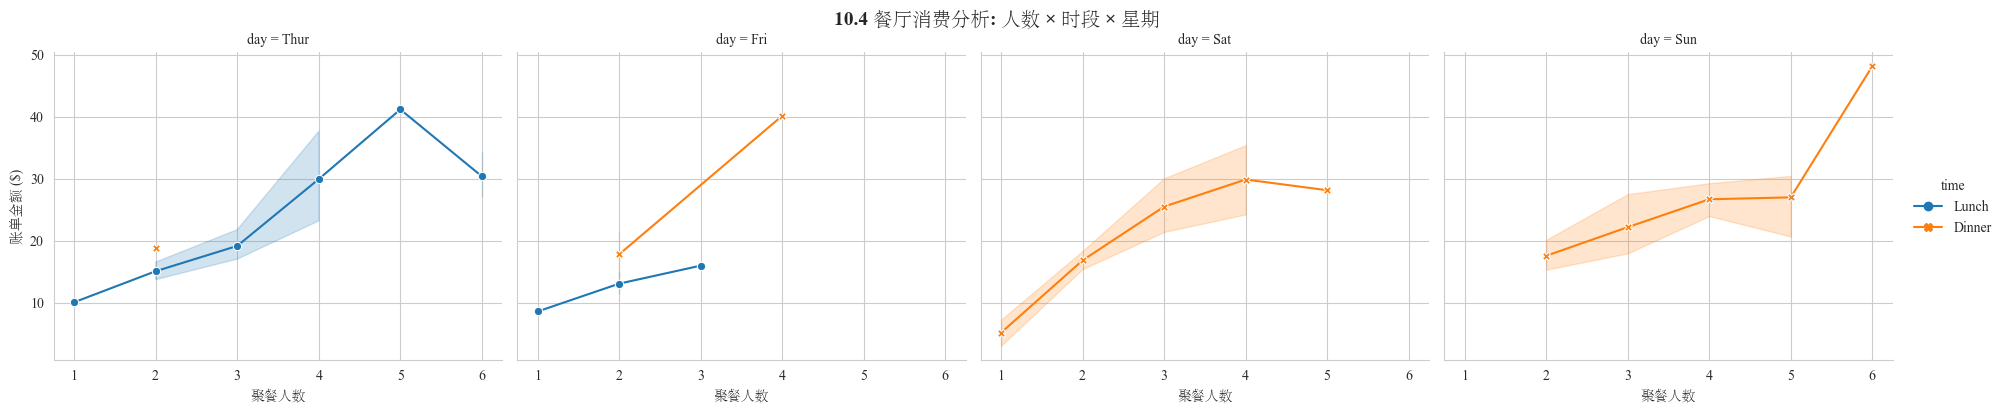

In [23]:
# ============================================================
# 画布 10: 综合应用案例
# ============================================================
print("\n画布 10: 综合应用案例")  # 打印画布10标题:空行+综合应用主题
print("-" * 60)  # 打印60个连字符:子画布分隔线

# ========== 10.1 精美散点图 ==========
g = sns.relplot(data=penguins,  # 数据集:企鹅数据(333行)
                x='body_mass_g',  # X轴:体重(克),第1维
                y='flipper_length_mm',  # Y轴:鳍长(毫米),第2维
                hue='species',  # 颜色:3类物种→3种高饱和色,第3维
                size='bill_length_mm',  # 大小:喙长连续→大小渐变,第4维
                style='sex',  # 形状:2类性别→2种标记,第5维
                palette='husl',  # 调色板:husl(高饱和度均匀色相,视觉冲击强)
                sizes=(50, 250),  # 大小范围:最小50px,最大250px(突出差异)
                alpha=0.7,  # 透明度:70%不透明(30%透明,解决重叠)
                height=6,  # 分面高度:6英寸(大图展示)
                aspect=1.5)  # 宽高比:1.5(总宽9英寸,专业报告尺寸)
# 终极5维可视化:3物种×2性别=6组,每组大小渐变
g.fig.suptitle('10.1 精美散点图: 企鹅特征综合分析',  # 主标题:5维综合分析
               fontsize=14,  # 标题字体:14pt
               fontweight='bold',  # 标题粗体
               y=1.02)  # 标题位置:上方1.02倍
g.set_axis_labels('体重 (g)', '鳍长 (mm)', fontsize=11)  # 统一轴标签+11pt字体
plt.show()  # 显示第30个图形:专业级5维散点图

# ========== 10.2 多维度分面分析 ==========
g = sns.relplot(data=penguins,
                x='body_mass_g',  # X轴:第1维
                y='flipper_length_mm',  # Y轴:第2维
                hue='species',  # 颜色:3类→第3维
                style='sex',  # 形状:2类→第4维
                col='island',  # 列分面:3岛屿→3列,第5维
                palette='Set2',  # 调色板:Set2(柔和配色,适合分面)
                height=4,  # 分面高度:4英寸(3列紧凑)
                aspect=1.2)  # 宽高比:1.2(稍宽,平衡信息密度)
# 组合效果:3岛屿列×(3物种色×2性别形)=18组数据
g.fig.suptitle('10.2 多维度分析: 岛屿 × 物种 × 性别',  # 主标题:5维分面分析
               fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('体重 (g)', '鳍长 (mm)')
plt.show()  # 显示第31个图形:3列×4维散点图(18组)

# ========== 10.3 精美折线图报表 ==========
g = sns.relplot(data=flights,  # 数据集:航班数据(144行)
                x='year',  # X轴:年份(1949-1960)
                y='passengers',  # Y轴:乘客数(自动按年聚合月度数据)
                hue='month',  # 颜色分组:12个月→12种颜色
                kind='line',  # 图表类型:折线图
                palette='tab20',  # 调色板:tab20(20色分类调色板,适合12类)
                height=6,  # 高度:6英寸(大图展示)
                aspect=2,  # 宽高比:2(总宽12英寸,长条形专业报告图)
                linewidth=2)  # 线宽:2pt(清晰可见)
# 效果:12条不同颜色趋势线,清晰展示季节性
g.fig.suptitle('10.3 航空客流报表: 12个月历年趋势',  # 主标题:航空客流专业报表
               fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('年份', '乘客数 (千人)', fontsize=11)  # Y轴单位:千人
# 添加网格线:增强可读性
g.ax.grid(alpha=0.3, linestyle='--')  # 30%透明虚线网格
plt.show()  # 显示第32个图形:专业航空客流12月趋势图

# ========== 10.4 分组趋势对比 ==========
g = sns.relplot(data=tips,  # 数据集:小费数据(244行)
                x='size',  # X轴:聚餐人数(1-6人,分类型)
                y='total_bill',  # Y轴:账单金额
                hue='time',  # 颜色分组:午餐/晚餐→2色
                style='time',  # 线型分组:2种线型
                col='day',  # 列分面:星期四/五/六/日→4列
                kind='line',
                markers=True,  # 添加数据点标记
                dashes=False,  # 强制实线
                height=4,  # 分面高度:4英寸
                aspect=1.2,  # 宽高比:1.2
                errorbar=('ci', 95))  # 误差带:95%置信区间
# 组合效果:4星期列×(午餐/晚餐色+线型)=8条线,每条带95%置信区间
g.fig.suptitle('10.4 餐厅消费分析: 人数 × 时段 × 星期',  # 主标题:餐厅消费多维分析
               fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('聚餐人数', '账单金额 ($)')
plt.show()  # 显示第33个图形:4列×2时段×95%CI趋势图

In [24]:
# ============================================================
# 打印完整参数总结
# ============================================================
print("\n" + "="*60)
print("Seaborn relplot 完整参数总结 (v0.13.2+)")
print("="*60)
print("""
1. 基础参数:
   - data: 数据源(DataFrame)
   - x, y: 两个变量(必需)
   - hue: 颜色映射变量
   - size: 大小映射变量
   - style: 样式映射变量
   - kind: 图表类型 ⭐⭐⭐
     * 'scatter': 散点图(默认)
     * 'line': 折线图

2. 分面参数: ⭐⭐⭐
   - col: 列分面变量
   - row: 行分面变量
   - col_wrap: 控制每行列数(仅col时)
   - col_order, row_order: 分面顺序

3. 大小控制:
   - height: 每个子图高度(英寸)
   - aspect: 宽高比

4. 多维映射参数: ⭐⭐⭐
   - hue: 映射到颜色
     * 分类: 不同颜色
     * 连续: 渐变色
   - size: 映射到大小
     * sizes=(min, max): 大小范围
   - style: 映射到样式
     * scatter: 点形状
     * line: 线型
   - markers: 自定义标记形状列表
   - dashes: 自定义虚线样式

5. scatter特有参数:
   - s: 固定点大小
   - alpha: 透明度(0-1)
   - edgecolor: 点边框颜色
   - linewidth: 边框宽度

6. line特有参数: ⭐⭐⭐
   - estimator: 聚合函数
     * 'mean'(默认)
     * 'median', 'sum'等
   - errorbar: 误差表示
     * 'se': 标准误(默认)
     * 'sd': 标准差
     * 'ci': 置信区间
     * ('pi', 95): 预测区间
   - markers: True/False，是否添加标记点
   - dashes: True/False，是否使用虚线
   - sort: True/False，是否排序X轴
   - err_style: 误差带样式('band'/'bars')

7. 颜色参数:
   - palette: 调色板
   - hue_order: hue变量顺序
   - hue_norm: 颜色归一化

8. 样式参数:
   - style_order: style变量顺序

9. 图例控制:
   - legend: 图例显示
     * 'auto'(默认)
     * 'brief': 简化
     * 'full': 完整
     * False: 隐藏

10. 其他参数:
   - units: 分组单位(用于重复测量)
   - weights: 权重
   - facet_kws: FacetGrid参数字典

11. 两种kind的对比: ⭐⭐⭐
   ┌─────────────┬────────────┬────────────┬────────────┐
   │   特性      │  scatter   │    line    │  选择建议  │
   ├─────────────┼────────────┼────────────┼────────────┤
   │ 用途        │  关系      │  趋势      │  看需求    │
   │ X轴类型     │  任意      │  通常连续  │  时间用line│
   │ 数据聚合    │  不聚合    │  自动聚合  │  line强大  │
   │ 误差带      │  无        │  有        │  line优势  │
   │ 标记点      │  天然有    │  可选      │  scatter清晰│
   │ 适合场景    │  相关性    │  时间序列  │  按需选择  │
   └─────────────┴────────────┴────────────┴────────────┘

12. 多维映射策略: ⭐⭐⭐
   - 2维: X + Y (基础)
   - 3维: X + Y + hue (颜色)
   - 4维: X + Y + hue + size (颜色+大小)
   - 5维: X + Y + hue + size + style (颜色+大小+形状)
   - 6维: X + Y + hue + size + style + col (再加分面)
   
   建议: 最多使用4-5维，过多维度难以理解

13. kind='line'的聚合: ⭐⭐⭐
   - 自动按x分组
   - 使用estimator聚合y值
   - 显示误差带(errorbar)
   - 非常适合时间序列

14. 使用建议:
   ✓ 探索关系 → scatter
   ✓ 时间序列 → line
   ✓ 需要分面 → relplot (col/row)
   ✓ 多维信息 → 使用hue/size/style
   ✓ 大数据集 → 降低alpha
   ✓ 精细控制 → scatterplot/lineplot

15. 常见组合:
   - scatter + hue: 分组散点
   - scatter + hue + size: 气泡图
   - scatter + hue + size + style: 多维分析
   - line + hue: 多条线对比
   - line + col: 分面趋势
   - line + markers: 带标记折线

16. Relplot vs 普通函数:
   ┌─────────────┬────────────────┬────────────────┐
   │  特性       │  Figure-level  │  Axes-level    │
   │             │  (relplot)     │  (scatter等)   │
   ├─────────────┼────────────────┼────────────────┤
   │  创建画布   │  自动创建      │  需手动创建    │
   │  分面功能   │  内置col/row   │  需手动循环    │
   │  kind切换   │  一个函数      │  两个函数      │
   │  灵活性     │  较低          │  更高          │
   │  易用性     │  更简单        │  需更多代码    │
   └─────────────┴────────────────┴────────────────┘

17. 使用场景: ⭐⭐⭐
   ✓ 探索两变量关系
   ✓ 时间序列分析
   ✓ 多维度数据可视化
   ✓ 分面对比分析
   ✓ 趋势和模式识别
   ✓ 数据报表制作

18. 最佳实践:
   ⭐ scatter看相关，line看趋势
   ⭐ 合理使用多维映射(不超过5维)
   ⭐ 分面时注意sharey设置
   ⭐ line图添加markers便于读取
   ⭐ 大数据集调整alpha避免过度绘制
   ⭐ 使用palette统一配色方案
   ⭐ 时间序列优先考虑line

19. 典型工作流:
   1. 确定kind类型(scatter/line)
   2. 映射基础维度(x, y)
   3. 添加颜色分组(hue)
   4. 考虑size/style增加维度
   5. 使用col/row分面
   6. 调整样式参数
   7. 完成可视化

20. 注意事项:
   ⚠ relplot会创建新figure
   ⚠ 与displot/catplot一样是Figure-level
   ⚠ line会自动聚合数据
   ⚠ 多维映射不要过度使用
   ⚠ 注意图例的可读性
""")

print("\n" + "="*60)
print("Relplot教程完成！")
print("="*60)
print("✓ 展示了2种kind类型")
print("✓ 演示了多维映射(hue/size/style)")
print("✓ 提供了10组综合应用案例")
print("✓ 包含完整的参数对比表")
print("\nRelplot是关系数据可视化的最佳工具！")


Seaborn relplot 完整参数总结 (v0.13.2+)

1. 基础参数:
   - data: 数据源(DataFrame)
   - x, y: 两个变量(必需)
   - hue: 颜色映射变量
   - size: 大小映射变量
   - style: 样式映射变量
   - kind: 图表类型 ⭐⭐⭐
     * 'scatter': 散点图(默认)
     * 'line': 折线图

2. 分面参数: ⭐⭐⭐
   - col: 列分面变量
   - row: 行分面变量
   - col_wrap: 控制每行列数(仅col时)
   - col_order, row_order: 分面顺序

3. 大小控制:
   - height: 每个子图高度(英寸)
   - aspect: 宽高比

4. 多维映射参数: ⭐⭐⭐
   - hue: 映射到颜色
     * 分类: 不同颜色
     * 连续: 渐变色
   - size: 映射到大小
     * sizes=(min, max): 大小范围
   - style: 映射到样式
     * scatter: 点形状
     * line: 线型
   - markers: 自定义标记形状列表
   - dashes: 自定义虚线样式

5. scatter特有参数:
   - s: 固定点大小
   - alpha: 透明度(0-1)
   - edgecolor: 点边框颜色
   - linewidth: 边框宽度

6. line特有参数: ⭐⭐⭐
   - estimator: 聚合函数
     * 'mean'(默认)
     * 'median', 'sum'等
   - errorbar: 误差表示
     * 'se': 标准误(默认)
     * 'sd': 标准差
     * 'ci': 置信区间
     * ('pi', 95): 预测区间
   - markers: True/False，是否添加标记点
   - dashes: True/False，是否使用虚线
   - sort: True/False，是否排序X轴
   - err_style: 误差带样式('band'/'bars')

7. 颜色参数:
   - pa